In [ ]:
!pip install pennylane
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 83.2 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# --- 0. Import Library
import os
import json
import pickle
import hashlib
from datetime import datetime
from pathlib import Path
from dataclasses import dataclass, asdict, field
from enum import Enum
from typing import Tuple, List, Dict, Any, Optional
from collections import deque, Counter, defaultdict
from functools import partial
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from jax import tree_util as jtu
from jax import random, lax
import optax
import pennylane as qml
from pennylane import numpy as pnp
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm
import random as py_random

In [ ]:
import json
import hashlib
from dataclasses import dataclass, asdict, field
from typing import Optional

# --- 1. Hyperparameters

@dataclass
class ModelConfig:
    depth: int  # Ansatz depth
    n_D: int  # Number of qubits in the data register
    n_H: int  # Number of qubits in the hidden register
    seq_len: int  # Length of a single sequence (time step)

    @property
    def n_qubits(self) -> int:
        return self.n_D + self.n_H  # Total number of qubits


@dataclass
class DatasetConfig:
    csv_path: str
    # (Model 1: S&P500)
    total_days: Optional[int] = None
    map_exponent: Optional[int] = None  # Classify by grouping the 2**n_D normalized values into buckets of size 2**map_exponent
    # (Model 1: S&P500 & Model 2: Power)
    start_year: Optional[int] = None
    start_month: Optional[int] = None
    start_day: Optional[int] = None
    normalize_exponent: Optional[int] = None  # Defines the representable rate range
    # (Model 2: Power)
    target_year: Optional[int] = None
    target_month: Optional[int] = None
    target_day: Optional[int] = None
    target_weekday: Optional[int] = None  # 0 = Monday ~ 6 = Sunday
    # (Model 3: Digits)
    first_digit: Optional[int] = None
    second_digit: Optional[int] = None


@dataclass
class TrainingConfig:
    batch_size: int
    max_epochs: int
    learning_rate_init: float  # First peak of the learning rate
    learning_rate_min: float  # Lower bound of the learning rate
    plot_every_n_epochs: int  # Plotting interval (epochs) if not using the complex scheduler


@dataclass
class SchedulerConfig:
    restart_period_epochs: int  # Restart period (epochs) used in 'find' mode
    restart_period_multiplier: float  # Next period = previous period * multiplier
    restart_decay_rate: float  # In 'find' mode: next peak LR = previous peak LR * decay_rate
    warmup_step_ratio: float  # Warmup steps = fight-mode duration * ratio
    flee_warmup_bind: bool  # If True: warmup steps are bound to flee steps (equal)
    fight_end_use_warm_start: bool  # If True: after fight, LR linearly warms to the new peak LR


@dataclass
class LossConfig:
    mmd_sigma: float = 3.25  # RBF kernel sigma (Updated from 3.25 to 3.0)
    mmd_lambda: float = 0.45  # Weight for class-discrimination term (pure MMD = MMD between real class 0 and 1)
    mmd_k: float = 15.0  # Temperature for smooth-max when combining class-0 and class-1 losses


@dataclass
class ModeConfig:
    fight_blocks_restart: bool  # Prevent restarts while in fight mode
    fight_in_fight_threshold: float  # Threshold to enter super-fight from fight
    fight_in_fight_window: int  # Window size used to evaluate the super-fight trigger
    fight_decay_rate: float  # Exponential decay rate of LR while in fight mode
    super_fight_lr_boost: float  # Multiplier applied to LR in super-fight
    protection_proportion: float  # Early protection phase proportion of total training
    find_mode_sub_start: float  # Initial relative drop threshold to switch to fight
    find_mode_sub_end: float  # Final relative drop threshold (annealed over training)
    find_fight_rate: float  # LR ratio: find LR / fight LR
    patience_num: int  # Steps without improvement before fleeing from fight
    cooldown_steps: int  # Cooldown steps after a mode change
    stop_condition: int  # Maximum number of flee events before stopping
    ema_beta: float  # EMA smoothing factor for loss
    flee_steps: int  # Fixed flee steps if binding is disabled
    flee_noise_sigma: float  # Std of noise added during flee (if used)
    volatility_window: int  # Window size for volatility detection
    volatility_threshold_start: float  # Initial CV threshold for volatility trigger
    volatility_threshold_end: float  # Final CV threshold (annealed over training)
    volatility_patience: int  # Number of consecutive volatility strikes before triggering


@dataclass
class RegularizationConfig:
    weight_decay: float
    clip_norm: float


@dataclass
class CheckpointConfig:
    base_checkpoint_dir: str
    max_keep_checkpoints: int
    allow_hash_mismatch: bool


@dataclass
class ExperimentConfig:
    loss_function: str  # "nll" or "mmd"
    collapse_type: str  # "soft" or "hard"
    learning_mode: str  # "teacher_forcing" or "autoregressive"


@dataclass
class SchedulerToggleConfig:
    use_complex_scheduler: bool = True  # True: complex scheduler; False: cosine annealing without restarts


@dataclass
class Config:
    model: int = 1  # 1: S&P500, 2: Power Demand, 3: Digit Generation

    model_cfg: ModelConfig = field(init=False)
    dataset_cfg: DatasetConfig = field(init=False)
    training_cfg: TrainingConfig = field(init=False)
    scheduler_cfg: SchedulerConfig = field(init=False)
    scheduler_toggle_cfg: SchedulerToggleConfig = field(default_factory=SchedulerToggleConfig)
    mode_cfg: ModeConfig = field(init=False)
    regularization_cfg: RegularizationConfig = field(init=False)
    checkpoint_cfg: CheckpointConfig = field(init=False)
    loss_cfg: LossConfig = field(default_factory=LossConfig)
    exp_cfg: ExperimentConfig = field(init=False)

    def __post_init__(self):
        # Dynamically import and set parameters based on the model number
        if self.model == 1:  # S&P500
            self._set_model1_params()
        elif self.model == 2:  # Power Demand
            self._set_model2_params()
        elif self.model == 3:  # Digit Generation
            self._set_model3_params()
        else:
            raise ValueError(f"Invalid model: {self.model}. Model must be 1, 2, or 3.")

    def _set_model1_params(self):
        """Sets the parameters for Model 1: S&P500"""
        self.model_cfg = ModelConfig(depth=8, n_D=5, n_H=5, seq_len=10)
        self.dataset_cfg = DatasetConfig(
            total_days=200,
            map_exponent=1,
            start_year=2024,
            start_month=1,
            start_day=5,
            normalize_exponent=6,
            csv_path="https://raw.githubusercontent.com/w-jiwonchoi/HQRNN_dataset/main/model_1_snp.csv",
        )
        self.training_cfg = TrainingConfig(
            batch_size=64,
            max_epochs=1000,
            learning_rate_init=1.0,
            learning_rate_min=1e-7,
            plot_every_n_epochs=2000,
        )
        self.scheduler_cfg = SchedulerConfig(
            restart_period_epochs=20,
            restart_period_multiplier=2.0,
            restart_decay_rate=0.9,
            warmup_step_ratio=0.05,
            flee_warmup_bind=True,
            fight_end_use_warm_start=True,
        )
        self.mode_cfg = ModeConfig(
            fight_blocks_restart=True,
            fight_in_fight_threshold=0.5,
            fight_in_fight_window=40,
            fight_decay_rate=0.01,
            super_fight_lr_boost=0.5,
            protection_proportion=0.5,
            find_mode_sub_start=0.50,
            find_mode_sub_end=0.30,
            find_fight_rate=2.0,
            patience_num=100,
            cooldown_steps=10,
            stop_condition=10,
            ema_beta=0.90,
            flee_steps=0,
            flee_noise_sigma=0.0,
            volatility_window=50,
            volatility_threshold_start=0.40,
            volatility_threshold_end=0.30,
            volatility_patience=5,
        )
        self.regularization_cfg = RegularizationConfig(weight_decay=0.0, clip_norm=1e-6)
        self.checkpoint_cfg = CheckpointConfig(
            base_checkpoint_dir="",
            max_keep_checkpoints=5,
            allow_hash_mismatch=False,
        )

    def _set_model2_params(self):
        """Sets the parameters for Model 2: Power Demand"""
        self.model_cfg = ModelConfig(depth=5, n_D=6, n_H=6, seq_len=5)
        self.dataset_cfg = DatasetConfig(
            start_year=2024,
            start_month=1,
            start_day=3,
            target_year=2024,
            target_month=12,
            target_day=23,
            target_weekday=0,
            normalize_exponent=6,
            csv_path="https://raw.githubusercontent.com/w-jiwonchoi/HQRNN_dataset/main/model_2_power.csv",
        )
        self.training_cfg = TrainingConfig(
            batch_size=4,
            max_epochs=100,
            learning_rate_init=0.1,
            learning_rate_min=1e-6,
            plot_every_n_epochs=1000,
        )
        self.scheduler_cfg = SchedulerConfig(
            restart_period_epochs=120,
            restart_period_multiplier=2.0,
            restart_decay_rate=0.85,
            warmup_step_ratio=0.05,
            flee_warmup_bind=True,
            fight_end_use_warm_start=True,
        )
        self.mode_cfg = ModeConfig(
            fight_blocks_restart=True,
            fight_in_fight_threshold=0.5,
            fight_in_fight_window=60,
            fight_decay_rate=0.005,
            super_fight_lr_boost=0.5,
            protection_proportion=0.5,
            find_mode_sub_start=0.3,
            find_mode_sub_end=0.25,
            find_fight_rate=2.0,
            patience_num=150,
            cooldown_steps=40,
            stop_condition=15,
            ema_beta=0.95,
            flee_steps=10,
            flee_noise_sigma=0.01,
            volatility_window=100,
            volatility_threshold_start=0.12,
            volatility_threshold_end=0.08,
            volatility_patience=20,
        )
        self.regularization_cfg = RegularizationConfig(weight_decay=0.0, clip_norm=1e-6)
        self.checkpoint_cfg = CheckpointConfig(
            base_checkpoint_dir="",
            max_keep_checkpoints=5,
            allow_hash_mismatch=False,
        )

    def _set_model3_params(self):
        """Sets the parameters for Model 3: Digit Generation"""
        self.model_cfg = ModelConfig(depth=7, n_D=7, n_H=7, seq_len=7)
        self.dataset_cfg = DatasetConfig(
            first_digit=0,
            second_digit=1,
            csv_path="https://raw.githubusercontent.com/w-jiwonchoi/HQRNN_dataset/main/model_3_digit.csv",
        )
        self.training_cfg = TrainingConfig(
            batch_size=32,
            max_epochs=20000,  # Updated
            learning_rate_init=0.1,
            learning_rate_min=1e-08,
            plot_every_n_epochs=5000,
        )
        self.scheduler_cfg = SchedulerConfig(
            restart_period_epochs=128,  # Updated
            restart_period_multiplier=1.5,
            restart_decay_rate=0.9,
            warmup_step_ratio=0.1,
            flee_warmup_bind=True,
            fight_end_use_warm_start=True,
        )
        self.mode_cfg = ModeConfig(
            fight_blocks_restart=True,
            fight_in_fight_threshold=0.04,
            fight_in_fight_window=100,
            fight_decay_rate=0.001,
            super_fight_lr_boost=0.2,
            protection_proportion=0.15,  # Updated
            find_mode_sub_start=0.50,
            find_mode_sub_end=0.25,
            find_fight_rate=5.0,
            patience_num=500,  # Updated
            cooldown_steps=10,
            stop_condition=10,
            ema_beta=0.95,
            flee_steps=10,
            flee_noise_sigma=0.0,
            volatility_window=100,
            volatility_threshold_start=0.20,
            volatility_threshold_end=0.15,
            volatility_patience=5,
        )
        self.regularization_cfg = RegularizationConfig(weight_decay=0.001, clip_norm=0.001)
        self.checkpoint_cfg = CheckpointConfig(
            base_checkpoint_dir="/content/drive/MyDrive/tongsub/Unified/Exp/Mode/3/0119",
            max_keep_checkpoints=5,
            allow_hash_mismatch=False,
        )

    def to_dict(self):
        return asdict(self)

    def get_hash(self) -> str:
        d = self.to_dict()
        d.pop("model", None)

        if "training_cfg" in d:
            d["training_cfg"].pop("max_epochs", None)

        if "checkpoint_cfg" in d:
            d["checkpoint_cfg"].pop("base_checkpoint_dir", None)
            d["checkpoint_cfg"].pop("max_keep_checkpoints", None)
            d["checkpoint_cfg"].pop("allow_hash_mismatch", None)

        if "mode_cfg" in d:
            d["mode_cfg"].pop("protection_proportion", None)

        return hashlib.sha256(json.dumps(d, sort_keys=True).encode()).hexdigest()[:8]

In [ ]:
# --- 2. 3-Mode (Find - Flee - Fight) System

class Mode(Enum):
    FIND = "find"  # Wide search for good candidates
    FIGHT = "fight"  # Intensify work on the chosen candidate
    FLEE = "flee"  # Shift to a fresh search area


@dataclass
class UnifiedModeState:
    config: Config
    mode: Mode = Mode.FIND  # Current mode

    best_loss: float = float('inf')
    last_loss: float = float('inf')
    ema_loss: float = float('inf')
    no_improve: int = 0  # Steps without improvement in fight
    cooldown: int = 0  # Steps to wait before another mode change

    flee_left: int = 0
    fight_count: int = 0
    flee_count: int = 0

    finished: bool = False

    fight_entry_lr: float = 0.0  # LR at fight entry
    volatility_strikes: int = 0  # Consecutive volatility triggers in find

    is_super_fight: bool = False  # Super-fight
    super_fight_entry_epoch: int = -1
    super_fight_duration: int = 0

    cycle_warmup_steps_hint: int = 0
    fight_start_epoch: int = -1
    fight_end_epoch: int = -1
    last_restart_warm_start: bool = False

    def __post_init__(self):
        self.recent_losses = deque(maxlen=self.config.mode_cfg.volatility_window)  # Rolling window for volatility
        self.fight_best_hits = deque(maxlen=self.config.mode_cfg.fight_in_fight_window)  # Improvements history in fight


@dataclass
class ModeUpdateResult:
    mode_changed: bool = False
    should_save_best: bool = False
    should_generate_flee_samples: bool = False
    triggered_by_volatility: bool = False
    request_warm_start_after_fight: bool = False
    flee_bound_to_warmup: bool = False

In [ ]:
# --- 3. Scheduler

class Scheduler:
    def __init__(self, config: Config):
        self.config = config

        if not self.config.scheduler_toggle_cfg.use_complex_scheduler:
            print("Scheduler Mode: Simple Cosine Annealing")
            self.simple_cosine_schedule = optax.cosine_decay_schedule(
                init_value=self.config.training_cfg.learning_rate_init,
                decay_steps=self.config.training_cfg.max_epochs,
                alpha=self.config.training_cfg.learning_rate_min / self.config.training_cfg.learning_rate_init
            )
            self.cycles, self.current_cycle_idx, self.local_warmup_active = [], 0, False
            self.local_warmup_start, self.local_warmup_steps, self.local_warmup_target_peak = -1, 0, None
            self.fight_active, self.fight_start_step, self.fight_entry_lr = False, -1, 0.0
            return

        print("Scheduler Mode: Complex")
        self.cycles = self._build_cycle()
        self.current_cycle_idx = 0
        self.cycle_anchor_start = 0
        self.local_warmup_active = False
        self.local_warmup_start = -1
        self.local_warmup_steps = 0
        self.local_warmup_target_peak = None
        self.fight_active = False
        self.fight_start_step = -1
        self.fight_entry_lr = 0.0
        self.is_in_warm_start_decay = False

    def _build_cycle(self):
        cfg_s = self.config.scheduler_cfg
        total = self.config.training_cfg.max_epochs
        cycles, period, peak, made = [], max(1, int(cfg_s.restart_period_epochs)), float(self.config.training_cfg.learning_rate_init), 0
        while made < total:
            steps_in_cycle = min(period, total - made)
            cycles.append({"start_step": made,
                           "end_step": made + steps_in_cycle,
                           "steps": steps_in_cycle,
                           "peak_value": peak,
                           "is_final": (made + steps_in_cycle >= total)})
            made += steps_in_cycle
            if not cycles[-1]["is_final"]:
                period = max(1, int(period * cfg_s.restart_period_multiplier))
                peak *= cfg_s.restart_decay_rate
        return cycles

    @staticmethod
    def _cosine_w_cycle(step_in_cycle: int, cycle_info: dict, lr_min: float) -> float:
        total_steps = max(1, cycle_info["steps"])
        if step_in_cycle >= total_steps:
            return lr_min
        progress = step_in_cycle / total_steps
        cosine_val = 0.5 * (1.0 + jnp.cos(jnp.pi * progress))
        lr = lr_min + (cycle_info["peak_value"] - lr_min) * cosine_val
        return float(jnp.maximum(lr, lr_min))

    @staticmethod
    def _linear_warmup(t: int, T: int, lr_min: float, lr_peak: float) -> float:
        if T <= 0:
            return lr_peak
        s = max(0, min(t, T))
        return float(lr_min + (lr_peak - lr_min) * (s / T))

    def get_lr(self, step: int, mode_state: UnifiedModeState) -> Tuple[float, bool]:
        if not self.config.scheduler_toggle_cfg.use_complex_scheduler:
            lr = self.simple_cosine_schedule(step)
            return float(jnp.maximum(lr, self.config.training_cfg.learning_rate_min)), False

        lr_min = self.config.training_cfg.learning_rate_min
        mode_state.is_warming_up = False
        current = self.cycles[self.current_cycle_idx]

        if self.is_in_warm_start_decay and (step - self.cycle_anchor_start) >= current["steps"]:
            self.is_in_warm_start_decay = False

        is_fight_or_super = (mode_state.mode == Mode.FIGHT) or mode_state.is_super_fight

        if self.fight_active and not is_fight_or_super:
            self.fight_active = False
            mode_state.fight_end_epoch = step

            fight_len = max(1, step - (self.fight_start_step if self.fight_start_step >= 0 else step))
            ratio = float(self.config.scheduler_cfg.warmup_step_ratio)

            if self.config.scheduler_cfg.fight_end_use_warm_start:
                self.local_warmup_active = True
                self.local_warmup_start = step
                self.local_warmup_steps = max(1, int(round(fight_len * ratio)))

            prev_peak = float(current["peak_value"])
            total_epochs = max(1, self.config.training_cfg.max_epochs)
            decay = float(self.config.scheduler_cfg.restart_decay_rate)
            new_peak = prev_peak * decay * max(0.0, 1.0 - (fight_len / total_epochs))
            new_peak = max(new_peak, lr_min)

            if self.current_cycle_idx < len(self.cycles) - 1:
                self.current_cycle_idx += 1
            current = self.cycles[self.current_cycle_idx]
            current["peak_value"] = float(new_peak)
            self.cycle_anchor_start = step
            self.local_warmup_target_peak = float(new_peak) if self.config.scheduler_cfg.fight_end_use_warm_start else None
            mode_state.last_restart_warm_start = bool(self.config.scheduler_cfg.fight_end_use_warm_start)
            self.is_in_warm_start_decay = False

        if is_fight_or_super:
            if not self.fight_active:
                self.fight_active = True
                self.fight_start_step = step
                step_in_cycle = step - self.cycle_anchor_start
                baseline = self._cosine_w_cycle(step_in_cycle, current, lr_min) if not self.local_warmup_active else current["peak_value"]
                self.fight_entry_lr = max(float(baseline), float(mode_state.fight_entry_lr or 0.0))
                mode_state.fight_start_epoch = step
            progress = step - self.fight_start_step
            decay = self.config.mode_cfg.fight_decay_rate
            start_lr = max(self.fight_entry_lr, lr_min)
            lr = lr_min + (start_lr - lr_min) * jnp.exp(-decay * progress)
            return float(jnp.maximum(lr, lr_min)), False

        if self.local_warmup_active:
            t = step - self.local_warmup_start
            if t < self.local_warmup_steps:
                mode_state.is_warming_up = True
                target_peak = float(self.local_warmup_target_peak or current["peak_value"])
                lr = self._linear_warmup(t=t, T=self.local_warmup_steps, lr_min=lr_min, lr_peak=target_peak)
                return float(jnp.maximum(lr, lr_min)), False
            else:
                lr = float(self.local_warmup_target_peak or current["peak_value"])
                self.cycle_anchor_start = step
                self.local_warmup_active = False
                self.local_warmup_start = -1
                self.local_warmup_steps = 0
                self.local_warmup_target_peak = None
                self.is_in_warm_start_decay = True
                return float(jnp.maximum(lr, lr_min)), False

        step_in_cycle = step - self.cycle_anchor_start
        restart_happened = False

        if step_in_cycle >= current["steps"] and self.current_cycle_idx < len(self.cycles) - 1:
            self.current_cycle_idx += 1
            self.cycle_anchor_start = step
            current = self.cycles[self.current_cycle_idx]
            step_in_cycle = 0
            restart_happened = True
        elif step_in_cycle == 0 and step > 0:
            restart_happened = True

        warmup_steps_cycle = max(1, int(round(current["steps"] * float(self.config.scheduler_cfg.warmup_step_ratio))))
        mode_state.cycle_warmup_steps_hint = warmup_steps_cycle

        if step_in_cycle < warmup_steps_cycle and not self.is_in_warm_start_decay:
            mode_state.is_warming_up = True
            lr = self._linear_warmup(t=step_in_cycle, T=warmup_steps_cycle, lr_min=lr_min, lr_peak=current["peak_value"])
            return float(jnp.maximum(lr, lr_min)), restart_happened

        lr = self._cosine_w_cycle(step_in_cycle, current, lr_min)
        return float(jnp.maximum(lr, lr_min)), restart_happened

In [ ]:
# --- 4. Loss Tracker

@dataclass
class LossHistory:
    losses: Dict[str, List[float]] = field(default_factory=lambda: defaultdict(list))
    epochs: List[int] = field(default_factory=list)
    modes: List[str] = field(default_factory=list)
    learning_rates: List[float] = field(default_factory=list)
    restarts: List[bool] = field(default_factory=list)

    def add(
        self,
        epoch: int,
        loss_dict: Dict[str, float],
        mode: Mode,
        lr: float,
        restart_happened: bool = False,
    ):
        self.epochs.append(epoch)
        self.modes.append(mode.value)
        self.learning_rates.append(float(lr))
        self.restarts.append(bool(restart_happened))

        for name, value in (loss_dict or {}).items():
            self.losses[name].append(float(value))

In [ ]:
# --- 5. Mode Controller

class ModeController:
    def __init__(self, config: Config):
        self.cfg = config
        self.state = UnifiedModeState(config=self.cfg)

    def _enter_fight_mode(self, st: UnifiedModeState, current_lr: float, epoch: int, res: ModeUpdateResult):
        st.mode = Mode.FIGHT
        st.no_improve = 0
        st.cooldown = self.cfg.mode_cfg.cooldown_steps
        st.fight_count += 1
        st.fight_entry_lr = current_lr
        st.fight_best_hits.clear()
        st.is_super_fight = False
        st.super_fight_duration = 0
        st.volatility_strikes = 0
        st.recent_losses.clear()
        st.fight_start_epoch = epoch
        res.mode_changed = True

    def _check_super_fight(self, st: UnifiedModeState, epoch: int) -> bool:
        if len(st.fight_best_hits) < self.cfg.mode_cfg.fight_in_fight_window:
            return False

        hit_rate = sum(st.fight_best_hits) / len(st.fight_best_hits)

        if hit_rate >= self.cfg.mode_cfg.fight_in_fight_threshold and not st.is_super_fight and st.super_fight_duration == 0:
            st.is_super_fight = True
            st.super_fight_entry_epoch = epoch
            st.super_fight_duration = 1
            print(f"Super-Fight activated! Hit rate: {hit_rate:.2f}")
            return True

        elif st.is_super_fight:
            st.super_fight_duration += 1
            if st.super_fight_duration > 100:
                st.is_super_fight = False
                st.super_fight_duration = 0
                print(f"Super-Fight ended after 100 epochs")

        return False

    def update(self, total_loss: float, current_lr: float, epoch: int) -> ModeUpdateResult:
        st = self.state
        res = ModeUpdateResult()

        if st.finished:
            return res

        ema_prev = total_loss if st.ema_loss == float('inf') else st.ema_loss
        rel_drop = (ema_prev - total_loss) / (ema_prev + 1e-12)
        st.ema_loss = self.cfg.mode_cfg.ema_beta * ema_prev + (1.0 - self.cfg.mode_cfg.ema_beta) * total_loss

        if st.cooldown > 0:
            st.cooldown -= 1

        if epoch < self.cfg.training_cfg.max_epochs * self.cfg.mode_cfg.protection_proportion:
            st.last_loss = total_loss
            if total_loss < st.best_loss:
                st.best_loss = total_loss
                res.should_save_best = True
            return res

        improved_this_step = False
        if total_loss < st.best_loss:
            print(f"\nNew best total loss: {st.best_loss:.6f} -> {total_loss:.6f}")
            st.best_loss = total_loss
            improved_this_step = True
            res.should_save_best = True
            if st.mode == Mode.FIGHT:
                st.no_improve = 0
        elif st.mode == Mode.FIGHT:
            st.no_improve += 1

        if st.mode == Mode.FIND:
            progress = epoch / self.cfg.training_cfg.max_epochs
            dyn_drop = self.cfg.mode_cfg.find_mode_sub_start - (self.cfg.mode_cfg.find_mode_sub_start - self.cfg.mode_cfg.find_mode_sub_end) * progress
            dyn_volt = self.cfg.mode_cfg.volatility_threshold_start - (self.cfg.mode_cfg.volatility_threshold_start - self.cfg.mode_cfg.volatility_threshold_end) * progress

            volatility_triggered = False
            st.recent_losses.append(total_loss)
            if len(st.recent_losses) == self.cfg.mode_cfg.volatility_window:
                losses_arr = np.array(st.recent_losses)
                mean_loss, std_loss = np.mean(losses_arr), np.std(losses_arr)
                cv = std_loss / (mean_loss + 1e-12)
                if cv > dyn_volt:
                    st.volatility_strikes += 1
                else:
                    st.volatility_strikes = 0
                if st.volatility_strikes >= self.cfg.mode_cfg.volatility_patience:
                    volatility_triggered = True

            if st.flee_count >= self.cfg.mode_cfg.stop_condition:
                st.finished = True

            elif st.cooldown == 0 and improved_this_step:
                print("Entering FIGHT by breaking All-Time Best!")
                self._enter_fight_mode(st, current_lr, epoch, res)

            elif st.cooldown == 0 and rel_drop >= dyn_drop:
                print(f"\nEntering FIGHT via Sharp Drop (drop: {rel_drop:.4f} > {dyn_drop:.4f})")
                self._enter_fight_mode(st, current_lr, epoch, res)

            elif st.cooldown == 0 and volatility_triggered:
                print(f"\nEntering FIGHT via High Volatility (CV trigger)")
                self._enter_fight_mode(st, current_lr, epoch, res)
                res.triggered_by_volatility = True

        elif st.mode == Mode.FIGHT:
            st.fight_best_hits.append(improved_this_step)

            if self._check_super_fight(st, epoch):
                res.mode_changed = True

            if st.no_improve >= self.cfg.mode_cfg.patience_num and st.cooldown == 0:
                st.mode = Mode.FLEE
                st.cooldown = self.cfg.mode_cfg.cooldown_steps
                st.flee_count += 1
                st.is_super_fight = False
                st.super_fight_duration = 0

                st.fight_end_epoch = epoch
                fight_epochs = max(1, int(st.fight_end_epoch - (st.fight_start_epoch if st.fight_start_epoch >= 0 else epoch)))
                ratio = float(self.cfg.scheduler_cfg.warmup_step_ratio)
                flee_steps_from_fight = max(1, int(np.ceil(fight_epochs * ratio)))
                st.flee_left = flee_steps_from_fight

                res.mode_changed = True
                res.should_generate_flee_samples = True
                print(f"\nEntering FLEE after {st.no_improve} steps without improvement "
                      f"(fight_len={fight_epochs}, flee_left={st.flee_left}, ratio={ratio:.4f})")

        elif st.mode == Mode.FLEE:
            st.flee_left -= 1
            if st.flee_left <= 0 and st.cooldown == 0:
                st.mode = Mode.FIND
                st.no_improve = 0
                st.cooldown = self.cfg.mode_cfg.cooldown_steps
                st.ema_loss = total_loss
                res.mode_changed = True
                print("\nReturning to FIND mode.")

        st.last_loss = total_loss
        return res

    def get_lr_multiplier(self) -> float:
        if self.state.mode == Mode.FIGHT:
            base_multiplier = 1.0 / self.cfg.mode_cfg.find_fight_rate
            if self.state.is_super_fight:
                multiplier = base_multiplier * self.cfg.mode_cfg.super_fight_lr_boost
                return max(multiplier, 0.1)
            return base_multiplier
        return 1.0

In [ ]:
# --- 6. Checkpoint Manager

class CheckpointManager:
    def __init__(self, config: Config, hour: Optional[int] = None):
        self.config = config
        base_dir = Path(config.checkpoint_cfg.base_checkpoint_dir) / f"Q{config.model_cfg.n_D}D{config.model_cfg.depth}_B{config.training_cfg.batch_size}_h{config.get_hash()}"

        if config.model == 2 and hour is not None:
            self.exp_dir = base_dir / f"hour_{hour}"
        else:
            self.exp_dir = base_dir

        self.ckpt_dir = self.exp_dir / "ckpt"
        self.plots_dir = self.exp_dir / "plots"
        self.csv_dir = self.exp_dir / "csv"
        self.ckpt_dir.mkdir(parents=True, exist_ok=True)
        self.plots_dir.mkdir(parents=True, exist_ok=True)
        self.csv_dir.mkdir(parents=True, exist_ok=True)

        print(f"Checkpoint directory: {self.exp_dir}")

        config_path = self.exp_dir / "config.json"
        if not config_path.exists():
            with open(config_path, 'w') as f:
                json.dump(config.to_dict(), f, indent=4)
            print(f"Configuration saved to {config_path}")

        self.meta_path = self.exp_dir / "meta.json"
        self.meta = self._load_meta()
        print(f"CSV outputs will be saved to: {self.csv_dir}")

    def _load_meta(self) -> Dict[str, Any]:
        if self.meta_path.exists():
            try:
                with open(self.meta_path, "r") as f:
                    obj = json.load(f)
                obj.setdefault("checkpoints", [])
                obj.setdefault("best_epoch", None)
                obj.setdefault("best_loss", None)
                return obj
            except Exception:
                pass
        return {"checkpoints": [], "best_epoch": None, "best_loss": None}

    def _save_meta(self):
        tmp = self.meta_path.with_suffix(".tmp")
        with open(tmp, "w") as f:
            json.dump(self.meta, f, indent=2)
        os.replace(tmp, self.meta_path)

    def _register_ckpt(self, filename: str, epoch: int):
        entry = {"file": str(Path(filename).resolve()), "epoch": int(epoch)}
        self.meta["checkpoints"].append(entry)
        seen, uniq = set(), []
        for e in reversed(self.meta["checkpoints"]):
            fname = Path(e["file"]).name
            if fname in seen:
                continue
            seen.add(fname)
            uniq.append(e)
        self.meta["checkpoints"] = list(reversed(uniq))

    def _prune_old_checkpoints(self):
        max_keep = int(self.config.checkpoint_cfg.max_keep_checkpoints)
        if max_keep <= 0:
            return

        all_files = sorted(
            [p for p in self.ckpt_dir.glob("*.pkl")
             if p.name != "best.pkl" and not p.name.startswith("fight")],
            key=lambda p: p.stat().st_mtime,
            reverse=True
        )

        keep = all_files[:max_keep]
        drop = all_files[max_keep:]

        for p in drop:
            try:
                p.unlink()
            except Exception:
                pass

        current_files = {p.name for p in self.ckpt_dir.glob("*.pkl")}
        self.meta["checkpoints"] = [e for e in self.meta["checkpoints"] if Path(e["file"]).name in current_files]

    def _atomic_pickle_dump(self, path: Path, obj: Dict[str, Any]):
        tmp = path.with_suffix(".tmp")
        with open(tmp, "wb") as f:
            pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
        os.replace(tmp, path)

    def save_checkpoint(
        self,
        tag: str,
        epoch: int,
        params: Dict,
        opt_state: Any,
        mode_state: UnifiedModeState,
        rng_key: Any,
        loss_history: LossHistory = None,
    ):
        from dataclasses import fields

        mode_state_dict = {
            field.name: getattr(mode_state, field.name)
            for field in fields(mode_state)
        }
        mode_state_dict['mode'] = mode_state.mode.value
        mode_state_dict.pop('config', None)
        mode_state_dict['recent_losses'] = list(mode_state.recent_losses)
        mode_state_dict['fight_best_hits'] = list(mode_state.fight_best_hits)

        path = self.ckpt_dir / f"{tag}.pkl"

        data = {
            "params": jtu.tree_map(np.array, params),
            "opt_state": jtu.tree_map(np.array, opt_state),
            "mode_state": mode_state_dict,
            "epoch": int(epoch),
            "rng_key": np.asarray(rng_key, dtype=np.uint32).tolist(),
            "config": self.config.to_dict(),
        }
        if loss_history is not None:
            loss_history_dict = {
                "losses": dict(loss_history.losses),
                "epochs": loss_history.epochs,
                "modes": loss_history.modes,
                "learning_rates": loss_history.learning_rates,
                "restarts": loss_history.restarts,
            }
            data["loss_history"] = loss_history_dict

        self._atomic_pickle_dump(path, data)
        print(f"Saved '{tag}' checkpoint at epoch {epoch} -> {path}")

        self._register_ckpt(str(path), epoch)
        self._prune_old_checkpoints()
        self._save_meta()

    def save_epoch_checkpoint(self, epoch: int, *args, **kwargs):
        tag = f"e{int(epoch):06d}"
        return self.save_checkpoint(tag, epoch, *args, **kwargs)

    def save_last(self, epoch: int, *args, **kwargs):
        return self.save_checkpoint("last", epoch, *args, **kwargs)

    def save_best(self, epoch: int, best_loss: float, *args, **kwargs):
        self.meta["best_epoch"] = int(epoch)
        self.meta["best_loss"] = float(best_loss)
        return self.save_checkpoint("best", epoch, *args, **kwargs)

    def load_checkpoint(self, tag: str = "best"):
        path = self.ckpt_dir / f"{tag}.pkl"
        if not path.exists():
            if self.meta.get("checkpoints"):
                cand = self.meta["checkpoints"][-1]["file"]
                path = Path(cand)
                if not path.exists():
                    return None
            else:
                return None

        with open(path, "rb") as f:
            data = pickle.load(f)

        saved_cfg_dict = data.get("config", {})
        saved_model_num = saved_cfg_dict.get('model')
        if saved_model_num is None:
            raise ValueError("Checkpoint config is missing 'model' key.")

        saved_cfg = Config(model=saved_model_num)
        exp_cfg_backup = saved_cfg_dict.pop('exp_cfg', None)
        saved_cfg_dict.pop('model', None)

        for key, value_dict in saved_cfg_dict.items():
            if hasattr(saved_cfg, key) and value_dict is not None and isinstance(value_dict, dict):
                try:
                    field_type = type(getattr(saved_cfg, key))
                    setattr(saved_cfg, key, field_type(**value_dict))
                except TypeError:
                    print(f"Warning: Could not reload nested config key '{key}'. Using default.")

        if exp_cfg_backup:
            saved_cfg.exp_cfg = ExperimentConfig(**exp_cfg_backup)

        if saved_cfg.get_hash() != self.config.get_hash() and not self.config.checkpoint_cfg.allow_hash_mismatch:
            raise ValueError(f"Config hash mismatch! Checkpoint: {saved_cfg.get_hash()}, Current: {self.config.get_hash()}")

        params = jtu.tree_map(jnp.array, data['params'])
        opt_state = jtu.tree_map(jnp.array, data['opt_state'])

        mode_data = data["mode_state"]
        mode_data['mode'] = Mode(mode_data['mode'])

        mode_state = UnifiedModeState(config=self.config)
        for k, v in mode_data.items():
            if hasattr(mode_state, k):
                setattr(mode_state, k, v)

        mode_state.recent_losses = deque(mode_data.get('recent_losses', []), maxlen=self.config.mode_cfg.volatility_window)
        mode_state.fight_best_hits = deque(mode_data.get('fight_best_hits', []), maxlen=self.config.mode_cfg.fight_in_fight_window)

        epoch = int(data["epoch"])
        rng_key = jnp.asarray(data["rng_key"], dtype=jnp.uint32)

        loss_history = None
        if "loss_history" in data:
            loss_history_data = data["loss_history"]
            loss_history_data['losses'] = defaultdict(list, loss_history_data.get('losses', {}))
            loss_history = LossHistory(**loss_history_data)

        print(f"Resumed from '{tag}' checkpoint at epoch {epoch}")
        return params, opt_state, mode_state, epoch, rng_key, loss_history

In [ ]:
# --- 7. Quantum Model

class QuantumModel:
    def __init__(self, config: Config):
        self.config = config
        self.wires = list(range(config.model_cfg.n_qubits))
        self.dev = qml.device("default.qubit", wires=self.wires, shots=None)

        @qml.qnode(self.dev, interface="jax")
        def circuit_for_probs(params, h_state, x_row, label_idx, use_x: bool = True):
            self._circuit_content(params, h_state, x_row, label_idx, use_x)
            return qml.probs(wires=range(self.config.model_cfg.n_D))

        @qml.qnode(self.dev, interface="jax")
        def circuit_for_state(params, h_state, x_row, label_idx, use_x: bool = True):
            self._circuit_content(params, h_state, x_row, label_idx, use_x)
            return qml.state()

        self.circuit_for_probs = circuit_for_probs
        self.circuit_for_state = circuit_for_state

    def _circuit_content(self, params, h_state, x_row, label_idx, use_x):
        cfg = self.config.model_cfg
        qml.StatePrep(h_state, wires=range(cfg.n_D, cfg.n_qubits))
        for i in range(cfg.n_H):
            qml.RZ(params["label_embed"][label_idx, i], wires=cfg.n_D + i)
        if use_x:
            for i in range(cfg.n_D):
                qml.RY(jnp.pi * x_row[i], wires=i)
        self.ansatz(params, self.wires)

    def initialize_params(self, key, n_classes=2):
        cfg = self.config.model_cfg
        keys = random.split(key, 5)
        theta_1q = random.normal(keys[0], (cfg.depth, cfg.n_qubits, 3)) * jnp.sqrt(2.0 / (cfg.n_qubits * 3))
        theta_zzD = random.normal(keys[1], (cfg.depth, cfg.n_D)) * jnp.sqrt(2.0 / cfg.depth)
        theta_zzH = random.normal(keys[2], (cfg.depth, cfg.n_H)) * jnp.sqrt(2.0 / cfg.depth)
        theta_zzX = random.normal(keys[3], (min(cfg.n_D, cfg.n_H),)) * jnp.sqrt(2.0 / cfg.depth)
        label_embed = random.normal(keys[4], (n_classes, cfg.n_H)) * 0.1
        return {
            "theta_1q": theta_1q, "theta_zzD": theta_zzD,
            "theta_zzH": theta_zzH, "theta_zzX": theta_zzX,
            "label_embed": label_embed
        }

    def ansatz(self, params, wires):
        cfg = self.config.model_cfg
        for d in range(cfg.depth):
            for i in range(cfg.n_qubits):
                qml.U3(params["theta_1q"][d, i, 0], params["theta_1q"][d, i, 1], params["theta_1q"][d, i, 2], wires=wires[i])
            for i in range(cfg.n_D):
                qml.IsingZZ(params["theta_zzD"][d, i], wires=[i, (i + 1) % cfg.n_D])
            for i in range(cfg.n_H):
                qml.IsingZZ(params["theta_zzH"][d, i], wires=[cfg.n_D + i, cfg.n_D + (i + 1) % cfg.n_H])
            for i in range(min(cfg.n_D, cfg.n_H)):
                qml.IsingZZ(params["theta_zzX"][i], wires=[i, cfg.n_D + i])

In [ ]:
# --- 8-1. Model1 & 2 Data Handler Base

class TimeSeriesDataHandler:
    def __init__(self, config: Config):
        self.config = config
        self.n_D = config.model_cfg.n_D
        self.exp = config.dataset_cfg.normalize_exponent
        self.M = 2 ** (self.n_D - 1)
        self.S = jnp.sum(1 / 2 ** jnp.arange(self.exp, self.exp + self.n_D - 1))
        self.X = None
        self.Y = None

    def _clip_rate(self, x):
        return jnp.clip(x, -self.S + 1e-8, self.S - 1e-8)

    def _normalize(self, x):
        x_clipped = self._clip_rate(jnp.asarray(x))
        idx_bin = jnp.rint((x_clipped / self.S + 1) * (self.M - 0.5)).astype(jnp.int32)
        powers = 2 ** jnp.arange(self.n_D - 1, -1, -1)
        return (jnp.floor_divide(idx_bin, powers) % 2).astype(jnp.int32)

    def _denormalize(self, bits):
        idx = jnp.sum(bits * (2 ** jnp.arange(self.n_D - 1, -1, -1)), axis=-1)
        x = ((idx / (self.M - 0.5)) - 1) * self.S
        return x.astype(jnp.float32)

    def _value_to_int(self, bits):
        powers = 2 ** jnp.arange(bits.shape[-1] - 1, -1, -1)
        return jnp.sum(bits * powers).astype(jnp.int32)

In [ ]:
# --- 8-2. Model1 Data Handler

class SnpDataHandler(TimeSeriesDataHandler):
    def __init__(self, config: Config):
        super().__init__(config)
        self.X_train, self.Y_train = None, None
        self.X_test, self.Y_test = None, None
        self.original_values = None
        self.train_size = 0
        self.dist_map = None
        self.context_bins = None
        self.context_assignments_train = None
        self._load_and_prep_data()
        self._create_dist_map()

    def _load_and_prep_data(self):
        print("Loading and preparing S&P 500 data...")
        df = pd.read_csv(self.config.dataset_cfg.csv_path)

        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date').reset_index(drop=True)

        ds_cfg = self.config.dataset_cfg
        start_date_str = f"{ds_cfg.start_year}-{ds_cfg.start_month:02d}-{ds_cfg.start_day:02d}"
        start_date = pd.to_datetime(start_date_str)

        df = df[df['Date'] >= start_date].reset_index(drop=True)
        print(f"Data filtered to start from: {start_date.date()}")

        if ds_cfg.total_days is not None:
            df = df.head(ds_cfg.total_days + self.config.model_cfg.seq_len + 1)
            print(f"Data limited to total {len(df)} records for sequence generation.")

        print(f"Data date range being used: {df['Date'].min()} to {df['Date'].max()}")

        self.original_values = df['Open'].values
        rates = (self.original_values[1:] - self.original_values[:-1]) / self.original_values[:-1]

        seq_len = self.config.model_cfg.seq_len
        X, Y = [], []
        for i in range(len(rates) - seq_len):
            x_seq_rates = rates[i: i + seq_len]
            y_rate = rates[i + seq_len]

            x_seq_bits = jax.vmap(self._normalize)(x_seq_rates)
            y_label = self._value_to_int(self._normalize(y_rate))

            X.append(x_seq_bits)
            Y.append(y_label)

        X_full, Y_full = jnp.stack(X), jnp.array(Y)

        self.train_size = int(len(X_full) * 0.8)
        self.X_train, self.X_test = jnp.split(X_full, [self.train_size])
        self.Y_train, self.Y_test = jnp.split(Y_full, [self.train_size])

        print(f"Created {len(X_full)} total sequences.")
        print(f"Data split into {len(self.X_train)} training and {len(self.X_test)} testing samples.")

    def _create_dist_map(self):
        mdl_cfg = self.config.model_cfg
        n_D = mdl_cfg.n_D
        K = 2 ** n_D
        seq_len = mdl_cfg.seq_len
        num_cases = K
        group_size = 1

        all_bits = jnp.array([[(i >> (n_D - 1 - j)) & 1 for j in range(n_D)] for i in range(K)])
        rate_lookup_table = self._denormalize(all_bits)

        initial_boundaries = [rate_lookup_table[i * group_size] for i in range(num_cases)]
        initial_boundaries.append(rate_lookup_table[-1] + (rate_lookup_table[-1] - rate_lookup_table[-2]))
        initial_boundaries = jnp.array(initial_boundaries)

        min_rate_repre = initial_boundaries[0]
        max_rate_repre = initial_boundaries[-1]

        train_indices = jnp.arange(self.train_size)
        start_values = self.original_values[train_indices]
        end_values = self.original_values[train_indices + seq_len]

        train_contexts = (end_values / start_values) - 1.0
        clipped_contexts = jnp.clip(train_contexts, min_rate_repre, max_rate_repre - 1e-9)

        initial_assignments = jnp.digitize(clipped_contexts, initial_boundaries) - 1
        initial_assignments = jnp.clip(initial_assignments, 0, num_cases - 1)

        case_counts = np.bincount(initial_assignments, minlength=num_cases)
        final_boundaries = list(initial_boundaries)

        for i in range(num_cases - 1, -1, -1):
            if case_counts[i] == 0:
                if i == num_cases - 1:
                    final_boundaries.pop(-2)
                elif i == 0:
                    final_boundaries.pop(1)
                else:
                    lower_b = final_boundaries[i]
                    upper_b = final_boundaries[i + 1]
                    mid_point = (lower_b + upper_b) / 2.0
                    final_boundaries.pop(i + 1)
                    final_boundaries[i] = mid_point

        self.context_bins = jnp.array(final_boundaries)
        final_assignments = jnp.digitize(clipped_contexts, self.context_bins) - 1
        final_assignments = jnp.clip(final_assignments, 0, len(self.context_bins) - 2)

        self.context_assignments_train = final_assignments
        num_final_cases = len(self.context_bins) - 1
        dist_map = {i: jnp.zeros(K, dtype=jnp.float32) for i in range(num_final_cases)}
        final_case_counts = {i: 0 for i in range(num_final_cases)}

        for cid, label in zip(final_assignments, self.Y_train):
            cid = int(cid)
            dist_map[cid] = dist_map[cid].at[label].add(1)
            final_case_counts[cid] += 1

        for i in range(num_final_cases):
            if final_case_counts[i] > 0:
                dist_map[i] /= final_case_counts[i]
            else:
                dist_map[i] = jnp.full(K, 1.0 / K)

        self.dist_map = jnp.stack([dist_map[i] for i in range(num_final_cases)])

    def create_batch(self, key, batch_size):
        num_samples = self.X_train.shape[0]
        indices = random.choice(key, num_samples, (min(batch_size, num_samples),), replace=False)
        X_batch = self.X_train[indices]
        Y_batch = self.Y_train[indices]
        C_batch = self.context_assignments_train[indices]
        Y_expanded = jnp.zeros((len(indices), self.config.model_cfg.seq_len), dtype=jnp.int32)
        Y_expanded = Y_expanded.at[:, -1].set(Y_batch)
        L_batch = jnp.zeros(len(indices), dtype=jnp.int32)
        return X_batch, Y_expanded, L_batch, C_batch

In [ ]:
# --- 8-3. Model2 Data Handler

class PowerDataHandler(TimeSeriesDataHandler):
    def __init__(self, config: Config):
        super().__init__(config)
        print("Loading Power Demand data...")
        self.df = pd.read_csv(self.config.dataset_cfg.csv_path)
        self.df['Date'] = pd.to_datetime(self.df['Date'])
        self.hourly_data = {}
        self.active_hour = -1

    def _remove_outliers(self, values):
        if len(values) < 4:
            return values
        values = np.array(values, dtype=float)
        rates = np.diff(values) / values[:-1]
        if len(rates) < 2:
            return values
        rate_jumps = np.abs(np.diff(rates))
        n_outliers = len(rate_jumps) // 10
        if n_outliers == 0:
            return values
        outlier_indices = np.argsort(rate_jumps)[-n_outliers:]
        print(f"Detected {n_outliers} potential outliers out of {len(values)} data points.")
        for rate_idx in sorted(outlier_indices, reverse=True):
            value_idx = rate_idx + 1
            if 0 < value_idx < len(values) - 1:
                values[value_idx] = (values[value_idx - 1] + values[value_idx + 1]) / 2
        return values

    def _compute_rates(self, values):
        pd.options.mode.chained_assignment = None
        cleaned_values = self._remove_outliers(values)
        rates = (cleaned_values[1:] - cleaned_values[:-1]) / cleaned_values[:-1]
        return np.nan_to_num(rates)

    def prepare_data_for_hour(self, hour: int):
        print(f"Preparing data for hour {hour}...")
        ds_cfg = self.config.dataset_cfg
        mdl_cfg = self.config.model_cfg

        target_date = pd.to_datetime(f"{ds_cfg.target_year}-{ds_cfg.target_month}-{ds_cfg.target_day}")
        start_date = pd.to_datetime(f"{ds_cfg.start_year}-{ds_cfg.start_month}-{ds_cfg.start_day}")

        df_weekday = self.df[self.df['Date'].dt.dayofweek == ds_cfg.target_weekday]
        train_df = df_weekday[(df_weekday['Date'] >= start_date) & (df_weekday['Date'] < target_date)]

        hour_col_str = str(hour)
        hour_col_padded = f"{hour:02d}"

        if hour_col_str in train_df.columns:
            hour_col = hour_col_str
        elif hour_col_padded in train_df.columns:
            hour_col = hour_col_padded
        else:
            print(f"Warning: Hour columns '{hour_col_str}' or '{hour_col_padded}' not found in data.")
            self.hourly_data[hour] = (None, None)
            return

        values = train_df[hour_col].values
        rates = self._compute_rates(values)

        X, Y = [], []
        for i in range(len(rates) - mdl_cfg.seq_len):
            x_seq_rates = rates[i: i + mdl_cfg.seq_len]
            y_rate = rates[i + mdl_cfg.seq_len]
            x_seq_bits = jax.vmap(self._normalize)(x_seq_rates)
            y_label = self._value_to_int(self._normalize(y_rate))
            X.append(x_seq_bits)
            Y.append(y_label)

        if not X:
            print(f"Warning: No data to train for hour {hour}.")
            self.hourly_data[hour] = (None, None)
        else:
            self.hourly_data[hour] = (jnp.stack(X), jnp.array(Y))
            print(f"Created {len(X)} sequences for hour {hour}.")

    def set_active_hour(self, hour: int):
        if hour not in self.hourly_data:
            self.prepare_data_for_hour(hour)
        self.active_hour = hour
        self.X, self.Y = self.hourly_data.get(hour, (None, None))

    def create_batch(self, key, batch_size):
        if self.X is None or len(self.X) == 0:
            return None, None, None
        num_samples = self.X.shape[0]
        indices = random.choice(key, num_samples, (min(batch_size, num_samples),), replace=False)
        X_batch = self.X[indices]
        Y_batch = self.Y[indices]
        Y_expanded = jnp.zeros((len(indices), self.config.model_cfg.seq_len), dtype=jnp.int32)
        Y_expanded = Y_expanded.at[:, -1].set(Y_batch)
        L_batch = jnp.zeros(len(indices), dtype=jnp.int32)
        return X_batch, Y_expanded, L_batch

In [ ]:
# --- 8-4. Model3 Data Handler

class DigitDataHandler:
    def __init__(self, config: Config):
        self.config = config
        self.target_mmd_r0_r1: Optional[float] = None
        self.X0, self.Y0, self.X1, self.Y1 = self._load_and_prep_data()

    @staticmethod
    def _bits_to_int(bits_1d: np.ndarray) -> int:
        n = bits_1d.shape[0]
        pow2 = 2 ** np.arange(n - 1, -1, -1, dtype=np.int64)
        return int(np.sum(bits_1d.astype(np.int64) * pow2))

    def _prep_case_7x7(self, images: np.ndarray, labels: np.ndarray,
                         d0: int, d1: int, mdl_cfg: ModelConfig):
        n_samples = len(images)
        X = np.zeros((n_samples, mdl_cfg.seq_len, mdl_cfg.n_D), dtype=np.int32)
        Y = np.zeros((n_samples, mdl_cfg.seq_len), dtype=np.int32)

        for i in range(n_samples):
            for t in range(1, mdl_cfg.seq_len):
                X[i, t] = images[i, t - 1]
            for t in range(mdl_cfg.seq_len):
                Y[i, t] = self._bits_to_int(images[i, t])

        mask0 = (labels == d0); mask1 = (labels == d1)
        return jnp.array(X[mask0]), jnp.array(Y[mask0]), jnp.array(X[mask1]), jnp.array(Y[mask1])

    def _load_and_prep_data(self):
        ds_cfg = self.config.dataset_cfg
        mdl_cfg = self.config.model_cfg
        try:
            df = pd.read_csv(ds_cfg.csv_path)
        except Exception as e:
            print(f"Error reading CSV from {ds_cfg.csv_path}: {e}")
            raise

        if (mdl_cfg.n_D, mdl_cfg.n_H, mdl_cfg.seq_len) != (7, 7, 7):
            raise ValueError(
                f"Unsupported (n_D, n_H, seq_len)={mdl_cfg.n_D, mdl_cfg.n_H, mdl_cfg.seq_len}. "
                "Only (7,7,7) is supported for model3. "
            )

        images, labels = [], []
        digits = [ds_cfg.first_digit, ds_cfg.second_digit]
        for _, row in df.iterrows():
            label = int(row["label"])
            if label in digits:
                image = (row.iloc[1:50].values > 0.5).astype(np.int32).reshape(7, 7)
                images.append(image)
                labels.append(label)
        images, labels = np.array(images), np.array(labels)

        return self._prep_case_7x7(images, labels, ds_cfg.first_digit, ds_cfg.second_digit, mdl_cfg)

    def create_batch(self, key, batch_size):
        key0, key1 = random.split(key)
        b0 = batch_size // 2
        b1 = batch_size - b0

        idx0 = random.choice(key0, len(self.X0), (min(b0, len(self.X0)),), replace=False)
        idx1 = random.choice(key1, len(self.X1), (min(b1, len(self.X1)),), replace=False)

        Xb = jnp.concatenate([self.X0[idx0], self.X1[idx1]], 0)
        Yb = jnp.concatenate([self.Y0[idx0], self.Y1[idx1]], 0)
        Lb = jnp.concatenate([jnp.zeros(len(idx0), jnp.int32), jnp.ones(len(idx1), jnp.int32)], 0)  # Class labels {0,1}
        Cb = jnp.zeros(len(Lb), dtype=jnp.int32)

        return Xb.astype(jnp.float32), Yb, Lb, Cb

    def calculate_target_mmd(self, n_samples: int = 1024, sigma: float = 1.5) -> float:
        if self.target_mmd_r0_r1 is not None:
            return self.target_mmd_r0_r1

        print(f"Calculating target MMD between real 0s and 1s using up to {n_samples} samples...")

        X0, Y0, X1, Y1 = self.X0, self.Y0, self.X1, self.Y1

        n0 = int(min(n_samples // 2, Y0.shape[0]))
        n1 = int(min(n_samples // 2, Y1.shape[0]))
        if n0 == 0 or n1 == 0:
            self.target_mmd_r0_r1 = 0.0
            print("Not enough samples to compute target MMD.")
            return self.target_mmd_r0_r1

        Y0 = Y0[:n0]
        Y1 = Y1[:n1]

        D = self.config.model_cfg.n_D
        bit_table = jnp.array([[(j >> (D - 1 - i)) & 1 for i in range(D)] for j in range(2 ** D)], dtype=jnp.float32)
        R0_bits = bit_table[Y0]
        R1_bits = bit_table[Y1]

        R0 = R0_bits.reshape(n0, -1)
        R1 = R1_bits.reshape(n1, -1)

        gamma = 1.0 / (2.0 * sigma ** 2)

        def _rbf_kernel(A, B):
            diff = A[:, None, :] - B[None, :, :]
            dist_sq = jnp.sum(diff * diff, axis=-1)
            return jnp.exp(-gamma * dist_sq)

        def _mmd_from_sets(P, Q):
            if P.shape[0] == 0 or Q.shape[0] == 0:
                return 0.0
            Kpp = jnp.mean(_rbf_kernel(P, P))
            Kqq = jnp.mean(_rbf_kernel(Q, Q))
            Kpq = jnp.mean(_rbf_kernel(P, Q))
            return Kpp - 2.0 * Kpq + Kqq

        target_mmd = _mmd_from_sets(R0, R1)
        self.target_mmd_r0_r1 = float(target_mmd)
        print(f"Calculated Target MMD(R0 bits, R1 bits): {self.target_mmd_r0_r1:.6f}")
        return self.target_mmd_r0_r1

In [ ]:
# --- 9-1. Model1 Visualizer

class SnpVisualizer:
    def __init__(self, config: Config, q_model: QuantumModel):
        self.config = config
        self.q_model = q_model
        self.data_handler = None

    def set_data_handler(self, data_handler):
        self.data_handler = data_handler

    @partial(jax.jit, static_argnames=['self'])
    def _predict_next(self, params, key, x_sequence):
        mdl_cfg = self.config.model_cfg
        n_D = mdl_cfg.n_D
        powers = 2 ** jnp.arange(n_D - 1, -1, -1)
        h_state = jnp.zeros(2**mdl_cfg.n_H, dtype=jnp.complex64).at[0].set(1.0)

        def _sample_from_probs(params, h_state, x_row, label_idx, key):
            sample_key, _ = random.split(key)
            probs = self.q_model.circuit_for_probs(params, h_state, x_row, label_idx)
            probs_clipped = jnp.clip(probs, 0.0, 1.0)
            probs_normalized = probs_clipped / (jnp.sum(probs_clipped) + 1e-9)
            measured_int = random.categorical(sample_key, jnp.log(probs_normalized))
            sample_bits = (jnp.floor_divide(measured_int, powers) % 2).astype(jnp.int32)
            return sample_bits, measured_int

        def body_fun(t, carry):
            h_state, key = carry
            key, subkey = random.split(key)
            x_t = x_sequence[t].astype(jnp.float32)
            sample_bits, measured_int = _sample_from_probs(params, h_state, x_t, 0, subkey)
            full_state = self.q_model.circuit_for_state(params, h_state, x_t, 0)
            psi_matrix = jnp.reshape(full_state, (2**mdl_cfg.n_H, 2**mdl_cfg.n_D))
            h_unnormalized = psi_matrix[:, measured_int]
            h_norm = jnp.linalg.norm(h_unnormalized)
            h_next = jnp.where(h_norm > 1e-9, h_unnormalized / h_norm, h_state)
            return (h_next, subkey)

        h_state, key = lax.fori_loop(0, mdl_cfg.seq_len, body_fun, (h_state, key))
        last_input = x_sequence[-1].astype(jnp.float32)
        final_sample_bits, _ = _sample_from_probs(params, h_state, last_input, 0, key)

        return final_sample_bits

    def visualize_samples(self, params, key, epoch, ckpt_manager: CheckpointManager, mode_state: UnifiedModeState,
                          save_to_disk=True, tag=""):
        if self.data_handler is None:
            print("Error: Data handler not set in Visualizer.")
            return

        print("Generating predictions...")
        mdl_cfg = self.config.model_cfg
        X_full = jnp.concatenate([self.data_handler.X_train, self.data_handler.X_test], axis=0)
        num_predictions = len(X_full)
        key, pred_key = random.split(key, 2)

        print(f"Predicting rates...")
        pred_keys = random.split(pred_key, num_predictions)
        pred_bits_list = []
        for i in tqdm(range(num_predictions), desc="Prediction"):
            bits_i = self._predict_next(params, pred_keys[i], X_full[i])
            pred_bits_list.append(bits_i)
        all_pred_bits = jnp.stack(pred_bits_list, axis=0)

        all_pred_bits_reshaped = all_pred_bits.reshape(num_predictions, 1, -1)
        pred_predicted_rates = jax.vmap(self.data_handler._denormalize)(all_pred_bits_reshaped).flatten()
        pred_predicted_rates = [float(r) for r in pred_predicted_rates]

        start_idx = mdl_cfg.seq_len
        start_value = self.data_handler.original_values[start_idx]
        actual_values = self.data_handler.original_values[start_idx: start_idx + num_predictions + 1]

        pred_pred_values = [start_value]
        for rate in pred_predicted_rates:
            pred_pred_values.append(pred_pred_values[-1] * (1 + rate))

        actual_values_full = list(self.data_handler.original_values[start_idx - mdl_cfg.seq_len: start_idx]) + list(actual_values)
        pred_values_full = list(self.data_handler.original_values[start_idx - mdl_cfg.seq_len: start_idx]) + pred_pred_values

        actual_seq_directions = []
        pred_seq_directions = []
        for i in range(1, num_predictions + 1):
            actual_start = actual_values_full[i]
            actual_end = actual_values_full[i + mdl_cfg.seq_len]
            actual_change = actual_end - actual_start
            actual_seq_directions.append(1 if actual_change > 0 else 0)

            pred_start = pred_values_full[i]
            pred_end = pred_values_full[i + mdl_cfg.seq_len]
            pred_change = pred_end - pred_start
            pred_seq_directions.append(1 if pred_change > 0 else 0)

        direction_accuracy = sum([1 for a, p in zip(actual_seq_directions, pred_seq_directions) if a == p]) / len(actual_seq_directions) * 100

        actual_daily_rates = [(actual_values[i+1] - actual_values[i]) / actual_values[i] for i in range(num_predictions)]
        rate_mae = sum([abs(p - a) for a, p in zip(actual_daily_rates, pred_predicted_rates)]) / num_predictions * 100
        value_mae = sum([abs(p - a) for a, p in zip(actual_values, pred_pred_values)]) / (num_predictions + 1)

        if save_to_disk:
            days = range(num_predictions + 1)
            train_days = self.data_handler.train_size

            fig1, ax1 = plt.subplots(1, 1, figsize=(16, 8))
            fig1.suptitle(f'S&P 500 Prediction - Epoch {epoch}', fontsize=16)
            ax1.plot(days, actual_values, color='gray', linewidth=2.5, label='Actual')
            ax1.plot(days, pred_pred_values, color='firebrick', linewidth=2, linestyle='-', label='Prediction')
            ax1.axvline(x=train_days, color='r', linestyle=':', linewidth=2, label='Train/Test Split')
            ax1.set_xlabel('Day'); ax1.set_ylabel('Open Value'); ax1.legend(); ax1.grid(True, alpha=0.5)

            textstr = f'Direction Accuracy: {direction_accuracy:.1f}%\nRate_MAE: {rate_mae:.2f}%\nValue_MAE: {value_mae:.1f}'
            props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
            ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='left', bbox=props)

            plt.tight_layout(rect=[0, 0, 1, 0.96])

            img_path = ckpt_manager.plots_dir / f"SnP500_prediction_epoch_{epoch}{'_'+tag if tag else ''}.png"
            plt.savefig(img_path, dpi=150); plt.close(fig1)
            print(f"Prediction plot saved to {img_path}")
            print(f"Direction Accuracy: {direction_accuracy:.1f}%, Rate_MAE: {rate_mae:.2f}%, Value_MAE: {value_mae:.1f}")

            results_df = pd.DataFrame({
                'Day': range(num_predictions + 1),
                'Actual_Value': actual_values,
                'Predicted_Value': pred_pred_values,
            })
            csv_path = ckpt_manager.csv_dir / f"SnP500_prediction_epoch_{epoch}{'_'+tag if tag else ''}.csv"
            results_df.to_csv(csv_path, index=False)
            print(f"Prediction comparison CSV saved to {csv_path}")
        return direction_accuracy, rate_mae, value_mae

In [ ]:
# --- 9-2. Model2 Visualizer

class PowerVisualizer:
    def __init__(self, config: Config, q_model: QuantumModel):
        self.config = config
        self.q_model = q_model

    def visualize_samples(self, params, key, epoch, ckpt_manager: CheckpointManager, mode_state: UnifiedModeState,
                          save_to_disk=True, tag=""):
        pass

    @partial(jax.jit, static_argnames=['self'])
    def _predict_next_demand_probs(self, params, x_sequence):
        mdl_cfg = self.config.model_cfg
        h_state = jnp.zeros(2**mdl_cfg.n_H, dtype=jnp.complex64).at[0].set(1.0)

        for t in range(mdl_cfg.seq_len):
            x_t = x_sequence[t].astype(jnp.float32)
            probs = self.q_model.circuit_for_probs(params, h_state, x_t, 0)
            full_state = self.q_model.circuit_for_state(params, h_state, x_t, 0)
            psi_matrix = jnp.reshape(full_state, (2**mdl_cfg.n_H, 2**mdl_cfg.n_D))
            norms = jnp.linalg.norm(psi_matrix, axis=0, keepdims=True) + 1e-12
            h_state = jnp.sum((psi_matrix / norms) * jnp.sqrt(probs)[None, :], axis=1)
            h_state /= (jnp.linalg.norm(h_state) + 1e-12)
        last_input = x_sequence[-1].astype(jnp.float32)
        return self.q_model.circuit_for_probs(params, h_state, last_input, 0)

    def visualize_24hour_prediction(self, all_trained_params, data_handler, ckpt_manager: CheckpointManager):
        ds_cfg = self.config.dataset_cfg
        mdl_cfg = self.config.model_cfg

        _main_key = random.PRNGKey(42)
        _main_key, key = random.split(_main_key)

        target_date = pd.to_datetime(f"{ds_cfg.target_year}-{ds_cfg.target_month}-{ds_cfg.target_day}")
        df_target = data_handler.df[data_handler.df['Date'].dt.date == target_date.date()]
        if df_target.empty:
            print(f"No data found for target date {target_date.date()}"); return

        actual_demands, predicted_demands, prediction_errors, hours_with_models = [], [], [], []

        for hour in tqdm(range(1, 25), desc="Predicting 24-hour demand"):
            hour_col = str(hour)
            if hour not in all_trained_params or hour_col not in df_target.columns:
                continue

            hours_with_models.append(hour)
            params = all_trained_params[hour]
            actual_demand = df_target[hour_col].iloc[0]
            actual_demands.append(actual_demand)

            data_handler.set_active_hour(hour)
            if data_handler.X is not None and len(data_handler.X) > 0:
                last_sequence = data_handler.X[-1]
                pred_probs = self._predict_next_demand_probs(params, last_sequence)

                key, subkey = random.split(key)
                pred_label = random.choice(subkey, jnp.arange(2**mdl_cfg.n_D), p=pred_probs)

                pred_bits = jnp.array([(pred_label >> (mdl_cfg.n_D - 1 - i)) & 1 for i in range(mdl_cfg.n_D)])
                pred_rate = data_handler._denormalize(pred_bits.reshape(1, -1))[0]

                prev_week_date = target_date - pd.Timedelta(weeks=1)
                prev_week_data = data_handler.df[data_handler.df['Date'].dt.date == prev_week_date.date()]
                if not prev_week_data.empty and hour_col in prev_week_data.columns:
                    base_demand = prev_week_data[hour_col].iloc[0]
                    predicted_demand = base_demand * (1 + float(pred_rate))
                else:
                    predicted_demand = actual_demand
            else:
                predicted_demand = actual_demand
            predicted_demands.append(predicted_demand)
            prediction_errors.append(abs(predicted_demand - actual_demand))

        valid_indices = ~np.isnan(actual_demands) & ~np.isnan(predicted_demands)
        actual_valid = np.array(actual_demands)[valid_indices]
        predicted_valid = np.array(predicted_demands)[valid_indices]
        errors_valid = np.abs(actual_valid - predicted_valid)

        mae = np.mean(errors_valid) if len(errors_valid) > 0 else 0
        rmse = np.sqrt(np.mean(errors_valid**2)) if len(errors_valid) > 0 else 0
        mape = np.mean(errors_valid / (actual_valid + 1e-9) * 100) if len(actual_valid) > 0 else 0

        fig, ax = plt.subplots(1, 1, figsize=(14, 7))
        fig.suptitle(f'24-Hour Power Demand Prediction - {target_date.date()}', fontsize=16)
        ax.plot(hours_with_models, actual_demands, color='gray', linewidth=2.5, marker='o', label='Actual Demand')
        ax.plot(hours_with_models, predicted_demands, color='firebrick', linewidth=2, marker='s', linestyle='--', label='Predicted Demand')
        ax.set_xlabel('Hour of Day'); ax.set_ylabel('Power Demand'); ax.set_title('Actual vs. Predicted Demand')
        ax.legend(); ax.grid(True, alpha=0.5); ax.set_xticks(range(0, 25, 2))

        stats_text = (f"MAE: {mae:,.2f}\n" f"RMSE: {rmse:,.2f}\n" f"MAPE: {mape:.2f}%")
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='aliceblue', alpha=0.8))

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        filename = f"power_prediction_summary_{target_date.date()}.png"
        img_path = ckpt_manager.plots_dir / filename
        plt.savefig(img_path, dpi=150); plt.close()
        print(f"Power demand prediction plot saved to {img_path}")

        results_df = pd.DataFrame({
            'Hour': hours_with_models,
            'Actual_Demand': actual_demands,
            'Predicted_Demand': predicted_demands,
            'Absolute_Error': prediction_errors
        })
        csv_path = ckpt_manager.csv_dir / f"demand_prediction_{target_date.date()}.csv"
        results_df.to_csv(csv_path, index=False)
        print(f"Full prediction results saved to {csv_path}")

In [ ]:
# --- 9-3. Model3 Visualizer

class DigitVisualizer:
    def __init__(self, config: Config, q_model: QuantumModel):
        self.config = config
        self.q_model = q_model

    @partial(jax.jit, static_argnames=['self', 'label_idx'])
    def _generate_digit(self, params, key, label_idx):
        mdl = self.config.model_cfg
        if (mdl.n_D, mdl.n_H, mdl.seq_len) != (7, 7, 7):
            raise ValueError(f"DigitVisualizer supports only (7,7,7), got {(mdl.n_D, mdl.n_H, mdl.seq_len)}")

        D, T = mdl.n_D, mdl.seq_len
        powers = 2 ** jnp.arange(D - 1, -1, -1)
        h = jnp.zeros(2**mdl.n_H, dtype=jnp.complex64).at[0].set(1.0)
        cur = jnp.zeros(D, dtype=jnp.float32)

        def _sample_from_probs(params, h_state, x_row, label_idx, key):
            sample_key, _ = random.split(key)
            probs = self.q_model.circuit_for_probs(params, h_state, x_row, label_idx)
            probs = jnp.clip(probs, 0.0, 1.0)
            probs /= (jnp.sum(probs) + 1e-9)
            measured_int = random.categorical(sample_key, jnp.log(probs))
            bits = (jnp.floor_divide(measured_int, powers) % 2).astype(jnp.int32)
            return bits, measured_int

        def body_fun(t, state):
            h_state, x_t, key, rows = state
            key, subkey = random.split(key)
            bits, idx = _sample_from_probs(params, h_state, x_t, label_idx, subkey)
            full_state = self.q_model.circuit_for_state(params, h_state, x_t, label_idx)
            psi = jnp.reshape(full_state, (2**mdl.n_H, 2**D))
            h_unnorm = psi[:, idx]; h_norm = jnp.linalg.norm(h_unnorm)
            h_next = jnp.where(h_norm > 1e-9, h_unnorm / h_norm, h_state)
            return (h_next, bits.astype(jnp.float32), subkey, rows.at[t].set(bits))

        init = (h, cur, key, jnp.zeros((T, D), dtype=jnp.int32))
        _, _, _, rows = lax.fori_loop(0, T, body_fun, init)
        return rows

    def visualize_samples(self, params, key, epoch, ckpt_manager: CheckpointManager, mode_state: UnifiedModeState,
                          save_to_disk=False, n_samples_per_digit=5, tag=""):
        ds = self.config.dataset_cfg
        mdl = self.config.model_cfg
        if (mdl.n_D, mdl.n_H, mdl.seq_len) != (7, 7, 7):
            raise ValueError(f"DigitVisualizer supports only (7,7,7), got {(mdl.n_D, mdl.n_H, mdl.seq_len)}")

        fig, axes = plt.subplots(2, n_samples_per_digit, figsize=(3 * n_samples_per_digit, 6))
        if n_samples_per_digit == 1:
            axes = axes.reshape(2, 1)

        csv_data = []

        for row, d in enumerate([ds.first_digit, ds.second_digit]):
            label_idx = 0 if d == ds.first_digit else 1
            for col in range(n_samples_per_digit):
                key, sub = random.split(key)
                rows = self._generate_digit(params, sub, label_idx)
                img = np.array(rows, dtype=np.int32)

                flat_pixels = img.flatten()
                csv_row = [d] + flat_pixels.tolist()
                csv_data.append(csv_row)

                ax = axes[row, col]
                ax.imshow(img, cmap=ListedColormap(['midnightblue', 'gold']), vmin=0, vmax=1)
                ax.set_title(f'Generated Digit {d}')
                ax.set_xticks([]); ax.set_yticks([])

        fig.suptitle(f'Digit Generation - Epoch {epoch} | Loss: {mode_state.last_loss:.4f}', fontsize=14, y=0.95)
        plt.tight_layout(rect=[0, 0, 1, 0.93])

        if save_to_disk:
            path = ckpt_manager.plots_dir / f"digit_samples_epoch_{epoch}{'_' + tag if tag else ''}.png"
            plt.savefig(path, dpi=150, bbox_inches='tight'); plt.close()
            print(f"Digit samples saved to {path}")

            csv_columns = ['label'] + [str(i) for i in range(49)]
            df = pd.DataFrame(csv_data, columns=csv_columns)
            csv_path = ckpt_manager.csv_dir / f"Epoch {epoch}_digits{'_' + tag if tag else ''}.csv"
            df.to_csv(csv_path, index=False)
            print(f"Digit samples CSV saved to {csv_path}")
        else:
            plt.show()

In [ ]:
# --- 10. Plotting Utility

def save_loss_plot(plots_dir, config, loss_history: LossHistory, epoch: int, mode_state: UnifiedModeState):
    if not loss_history.epochs:
        return

    total_loss_history = loss_history.losses.get('total')

    fig, axs = plt.subplots(2, 2, figsize=(18, 10), gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(f'Training Analysis - Epoch {epoch}', fontsize=16)

    # (0,0) Loss curves
    ax = axs[0, 0]
    if total_loss_history:
        ax.plot(loss_history.epochs, total_loss_history, color='darkslateblue', linewidth=2, label='Total Loss')

    if config.model == 3:
        ds_cfg = config.dataset_cfg
        first_digit_loss = loss_history.losses.get('first_digit_loss')
        second_digit_loss = loss_history.losses.get('second_digit_loss')
        if first_digit_loss:
            ax.plot(loss_history.epochs, first_digit_loss, color='palevioletred', alpha=0.8, label=f'Digit {ds_cfg.first_digit} Loss')
        if second_digit_loss:
            ax.plot(loss_history.epochs, second_digit_loss, color='steelblue', alpha=0.8, label=f'Digit {ds_cfg.second_digit} Loss')
        ax.legend()

    ax.set_title('Loss Over Time'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.grid(True, alpha=0.3)

    # (0,1) LR curve
    ax = axs[0, 1]
    if len(loss_history.epochs) > 1:
        ax.plot(loss_history.epochs[1:], loss_history.learning_rates[1:], color='orange', linewidth=2)
    elif loss_history.epochs:
        ax.plot(loss_history.epochs, loss_history.learning_rates, color='orange', linewidth=2)

    # (1,0) Mode timeline
    ax = axs[1, 0]
    mode_colors = {'find': 'paleturquoise', 'fight': 'lightseagreen', 'flee': 'azure', 'super': 'darkslategrey'}
    mode_labels = {'find': 'Find', 'fight': 'Fight', 'flee': 'Flee', 'super': 'Super-Fight'}
    y_pos = 0.5; bar_height = 0.6; segment_start = 0; processed_modes = []
    for i, (mode_val, epoch_val) in enumerate(zip(loss_history.modes, loss_history.epochs)):
        is_super = (mode_state.super_fight_entry_epoch != -1 and
                    epoch_val >= mode_state.super_fight_entry_epoch and
                    mode_state.super_fight_entry_epoch + 100 > epoch_val and
                    mode_val == 'fight')
        display_mode = 'super' if is_super else mode_val
        processed_modes.append(display_mode)
        if i > 0 and display_mode != processed_modes[i - 1]:
            start_epoch = loss_history.epochs[segment_start]
            end_epoch = loss_history.epochs[i - 1]
            ax.barh(y_pos, end_epoch - start_epoch + 1, left=start_epoch, height=bar_height,
                    color=mode_colors.get(processed_modes[i - 1], 'gray'), alpha=0.7, edgecolor='black')
            segment_start = i
    if loss_history.epochs:
        start_epoch = loss_history.epochs[segment_start]
        end_epoch = loss_history.epochs[-1]
        ax.barh(y_pos, end_epoch - start_epoch + 1, left=start_epoch, height=bar_height,
                color=mode_colors.get(processed_modes[-1], 'gray'), alpha=0.7, edgecolor='black')
    handles = [plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.7) for color in mode_colors.values()]
    ax.legend(handles, mode_labels.values(), loc='upper right', ncol=len(mode_labels))
    ax.set_xlabel('Epoch'); ax.set_title('Mode Timeline'); ax.set_ylim(0, 1); ax.set_yticks([]); ax.grid(True, alpha=0.3, axis='x')

    # (1,1) Stats
    ax = axs[1, 1]; ax.axis('off')
    stats_text = f"Training Statistics (Epoch {epoch}):\n"
    if total_loss_history:
        stats_text += f"{'Total Loss':<15}: {total_loss_history[-1]:.6f}\n"
    stats_text += f"{'Current Mode':<15}: {mode_state.mode.value.upper()}\n"
    if mode_state.is_super_fight:
        stats_text += f"{'Super-Fight':<15}: Active\n"
    if loss_history.learning_rates:
        stats_text += f"{'Current LR':<15}: {loss_history.learning_rates[-1]:.2e}\n"
    stats_text += f"{'Best Loss':<15}: {mode_state.best_loss:.6f}\n\n"
    stats_text += f"Fight Count: {mode_state.fight_count}\n"
    stats_text += f"Flee Count:  {mode_state.flee_count}"
    ax.text(0.01, 0.95, stats_text, transform=ax.transAxes, fontsize=12, verticalalignment='top',
            fontfamily='monospace', bbox=dict(boxstyle='round,pad=0.5', fc='aliceblue', ec='grey', alpha=0.5))

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plot_path = plots_dir / f"training_analysis_epoch_{epoch}.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Training analysis plot saved to {plot_path}")

In [ ]:
# --- 11. Seed Management

def set_global_seed(seed: int):
    py_random.seed(seed)
    np.random.seed(seed)
    return random.PRNGKey(seed)

In [ ]:
# --- 12. Trainer - Autodiff

class Trainer_Autodiff:
    def __init__(self, config: Config, q_model: QuantumModel, data_handler, visualizer, ckpt_manager):
        self.config = config
        self.q_model = q_model
        self.data_handler = data_handler
        self.visualizer = visualizer
        self.ckpt_manager = ckpt_manager
        self.exp_cfg = config.exp_cfg
        self.loss_cfg = config.loss_cfg
        self.target_mmd_r0_r1 = None
        if self.config.model == 1:
            self.dist_map = data_handler.dist_map
            self.context_bins = data_handler.context_bins

    def _bits_to_int(self, bits):
        n_D = self.config.model_cfg.n_D
        powers = 2 ** jnp.arange(n_D - 1, -1, -1)
        return jnp.sum(bits * powers).astype(jnp.int32)

    def _step(self, carry, inputs, collapse_type):
        h_state, params, key = carry
        x_row, y_row, label_idx = inputs
        key, step_key, sample_key = random.split(key, 3)

        if collapse_type == 'hard':
            probs = self.q_model.circuit_for_probs(params, h_state, x_row, label_idx)
            full_state = self.q_model.circuit_for_state(params, h_state, x_row, label_idx)
            probs_clipped = jnp.clip(probs, 0.0, 1.0)
            probs_normalized = probs_clipped / (jnp.sum(probs_clipped) + 1e-9)
            measured_int = random.categorical(sample_key, jnp.log(probs_normalized))
            n_D = self.config.model_cfg.n_D
            powers = 2 ** jnp.arange(n_D - 1, -1, -1)
            sample_bits = (jnp.floor_divide(measured_int, powers) % 2).astype(jnp.int32)
            psi_matrix = jnp.reshape(full_state, (2**self.config.model_cfg.n_H, 2**self.config.model_cfg.n_D))
            h_unnormalized = psi_matrix[:, measured_int]
            h_norm = jnp.linalg.norm(h_unnormalized)
            h_next = jnp.where(h_norm > 1e-9, h_unnormalized / h_norm, h_state)
            h_next = jax.lax.stop_gradient(h_next)
            return (h_next, params, key), (probs, sample_bits)

        elif collapse_type == 'soft':
            probs = self.q_model.circuit_for_probs(params, h_state, x_row, label_idx)
            full_state = self.q_model.circuit_for_state(params, h_state, x_row, label_idx)
            psi_matrix = jnp.reshape(full_state, (2**self.config.model_cfg.n_H, 2**self.config.model_cfg.n_D))
            norms = jnp.linalg.norm(psi_matrix, axis=0, keepdims=True) + 1e-12
            h_next = jnp.sum((psi_matrix / norms) * jnp.sqrt(probs)[None, :], axis=1)
            h_next /= (jnp.linalg.norm(h_next) + 1e-12)
            probs_clipped = jnp.clip(probs, 0.0, 1.0)
            probs_normalized = probs_clipped / (jnp.sum(probs_clipped) + 1e-9)
            measured_int = random.categorical(sample_key, jnp.log(probs_normalized))
            n_D = self.config.model_cfg.n_D
            powers = 2 ** jnp.arange(n_D - 1, -1, -1)
            sample_bits = (jnp.floor_divide(measured_int, powers) % 2).astype(jnp.int32)
            return (h_next, params, key), (probs, sample_bits)
        else:
            raise ValueError(f"Unknown collapse type: {collapse_type}")

    def _forward_sequence(self, params, X, Y, L, key, learning_mode, collapse_type):
        mdl_cfg = self.config.model_cfg
        h_initial = jnp.zeros(2**mdl_cfg.n_H, dtype=jnp.complex64).at[0].set(1.0)
        K = 2**mdl_cfg.n_D

        if learning_mode == 'teacher_forcing':
            inputs = (X, Y, jnp.full(mdl_cfg.seq_len, L))
            step_fn = partial(self._step, collapse_type=collapse_type)
            _, (probs_seq, samples_seq) = lax.scan(step_fn, (h_initial, params, key), inputs, length=mdl_cfg.seq_len)
            return probs_seq, samples_seq

        elif learning_mode == 'autoregressive':
            def ar_body_fun(t, carry):
                h_state, prev_output_bits, key, all_probs, all_samples = carry
                key, step_key = random.split(key)
                current_input = lax.cond(
                    t == 0,
                    lambda: X[0].astype(jnp.float32),
                    lambda: prev_output_bits
                )
                inputs_t = (current_input, Y[t], L)
                (h_next, _, _), (probs, sample_bits) = self._step((h_state, params, step_key), inputs_t, collapse_type)
                all_probs = all_probs.at[t].set(probs)
                all_samples = all_samples.at[t].set(sample_bits)
                next_prev = sample_bits.astype(jnp.float32)
                return (h_next, next_prev, key, all_probs, all_samples)

            initial_carry = (
                h_initial,
                jnp.zeros((mdl_cfg.n_D,), dtype=jnp.float32),
                key,
                jnp.zeros((mdl_cfg.seq_len, K), dtype=jnp.float32),
                jnp.zeros((mdl_cfg.seq_len, mdl_cfg.n_D), dtype=jnp.int32),
            )
            _, _, _, probs_seq, samples_seq = lax.fori_loop(0, mdl_cfg.seq_len, ar_body_fun, initial_carry)
            return probs_seq, samples_seq

        else:
            raise ValueError(f"Unknown learning mode: {learning_mode}")


    def _nll_loss_fn(self, params, X, Y, L, C, key, learning_mode, collapse_type):
        vmapped_forward = jax.vmap(self._forward_sequence, in_axes=(None, 0, 0, 0, 0, None, None))
        probs_batch_seq, _ = vmapped_forward(params, X, Y, L, random.split(key, X.shape[0]), learning_mode, collapse_type)

        batch_indices = jnp.arange(Y.shape[0])

        if self.config.model == 1:
            probs_last_step = probs_batch_seq[:, -1, :]
            context_ids_batch = C
            target_dists = self.dist_map[context_ids_batch]
            log_probs = jnp.log(jnp.clip(probs_last_step, 1e-12, 1.0))
            loss_per_sample = -jnp.sum(target_dists * log_probs, axis=1)

        elif self.config.model == 2:
            probs_last_step = probs_batch_seq[:, -1, :]
            y_last_step = Y[:, -1]
            target_probs = probs_last_step[batch_indices, y_last_step]
            loss_per_sample = -jnp.log(jnp.clip(target_probs, 1e-12, 1.0))
        else:
            time_indices = jnp.arange(Y.shape[1])
            target_probs = probs_batch_seq[batch_indices[:, None], time_indices, Y]
            log_loss = -jnp.log(jnp.clip(target_probs, 1e-12, 1.0))
            loss_per_sample = jnp.mean(log_loss, axis=1)

        return jnp.mean(loss_per_sample), loss_per_sample

    def _mmd_loss_fn(self, params, X, Y, L, C, key, learning_mode, collapse_type):
        mdl_cfg = self.config.model_cfg
        loss_cfg = self.loss_cfg
        B, T, D = X.shape[0], mdl_cfg.seq_len, mdl_cfg.n_D

        vmapped_forward = jax.vmap(self._forward_sequence, in_axes=(None, 0, 0, 0, 0, None, None))
        probs_batch_seq, _ = vmapped_forward(params, X, Y, L, random.split(key, B), learning_mode, collapse_type)

        bit_table = jnp.array(
            [[(j >> (D - 1 - i)) & 1 for i in range(D)] for j in range(2**D)],
            dtype=jnp.float32
        )

        def _rbf(A, B, gamma):
            diff = A[:, None, :] - B[None, :, :]
            dist2 = jnp.sum(diff * diff, axis=-1)
            return jnp.exp(-gamma * dist2)

        if self.config.model == 1:
            sigma = self.loss_cfg.mmd_sigma
            gamma = 1.0 / (2 * sigma**2)

            context_ids_batch = C
            Q = self.dist_map[context_ids_batch]
            P = probs_batch_seq[:, -1, :]

            def rbf_kernel_y(A, B, gamma):
                diff = A[:, None, :] - B[None, :, :]
                dist2 = jnp.sum(diff * diff, axis=-1)
                return jnp.exp(-gamma * dist2)

            Kpp = rbf_kernel_y(P, P, gamma).mean()
            Kqq = rbf_kernel_y(Q, Q, gamma).mean()
            Kpq = rbf_kernel_y(P, Q, gamma).mean()

            total_loss = jnp.maximum(0.0, Kpp - 2.0 * Kpq + Kqq)
            loss_per_sample = jnp.full((B,), total_loss)
            return total_loss, loss_per_sample

        if self.config.model == 2:
            sigma = jnp.asarray(loss_cfg.mmd_sigma, dtype=jnp.float32)
            gamma = 1.0 / (2.0 * sigma**2)

            probs_last = probs_batch_seq[:, -1, :]
            Eb_last = probs_last @ bit_table
            y_bits_last = bit_table[Y[:, -1]]

            Kpp = _rbf(Eb_last, Eb_last, gamma).mean()
            Kqq = _rbf(y_bits_last, y_bits_last, gamma).mean()
            Kpq = _rbf(Eb_last, y_bits_last, gamma).mean()

            total_loss = Kpp - 2.0 * Kpq + Kqq
            loss_per_sample = jnp.full((B,), total_loss, dtype=jnp.float32)
            return total_loss, loss_per_sample

        sigma = jnp.asarray(loss_cfg.mmd_sigma, dtype=jnp.float32)
        gamma = 1.0 / (2.0 * sigma**2)
        lambda_dist = jnp.asarray(loss_cfg.mmd_lambda, dtype=jnp.float32)

        Eb = (probs_batch_seq @ bit_table).reshape(B, T * D)
        y_bits = bit_table[Y].reshape(B, T * D)

        def _mmd_masked(P, Q, mP, mQ):
            nP = jnp.sum(mP); nQ = jnp.sum(mQ)
            KP = _rbf(P, P, gamma); KQ = _rbf(Q, Q, gamma); KPQ = _rbf(P, Q, gamma)
            Mpp = mP[:, None] * mP[None, :]
            Mqq = mQ[:, None] * mQ[None, :]
            Mpq = mP[:, None] * mQ[None, :]
            term_pp = jnp.sum(KP * Mpp) / jnp.maximum(nP**2, 1e-9)
            term_qq = jnp.sum(KQ * Mqq) / jnp.maximum(nQ**2, 1e-9)
            term_pq = jnp.sum(KPQ * Mpq) / jnp.maximum(nP * nQ, 1e-9)
            ok = (nP > 0) & (nQ > 0)
            return jnp.where(ok, term_pp - 2.0 * term_pq + term_qq, 0.0)

        m0 = (L == 0).astype(jnp.float32)
        m1 = (L == 1).astype(jnp.float32)

        mmd_P0_R0 = _mmd_masked(Eb, y_bits, m0, m0)
        mmd_P1_R1 = _mmd_masked(Eb, y_bits, m1, m1)
        mmd_P0_R1 = _mmd_masked(Eb, y_bits, m0, m1)
        mmd_P1_R0 = _mmd_masked(Eb, y_bits, m1, m0)

        if self.target_mmd_r0_r1 is None:
            self.target_mmd_r0_r1 = float(getattr(self.data_handler, "calculate_target_mmd")(sigma=float(loss_cfg.mmd_sigma)))

        target = jnp.asarray(self.target_mmd_r0_r1, dtype=jnp.float32)

        L0 = mmd_P0_R0 + lambda_dist * (mmd_P0_R1 - target) ** 2
        L1 = mmd_P1_R1 + lambda_dist * (mmd_P1_R0 - target) ** 2

        k = jnp.asarray(loss_cfg.mmd_k, dtype=jnp.float32)
        total_loss = jax.nn.logsumexp(k * jnp.stack([L0, L1])) / k

        loss_per_sample = jnp.where((L == 0), L0, L1)
        return total_loss, loss_per_sample

    def run(self, seed=42):
        cfg = self.config
        key = set_global_seed(seed)

        n_classes = 2 if cfg.model == 3 else 1
        params = self.q_model.initialize_params(key, n_classes=n_classes)
        opt_core = optax.chain(
            optax.clip_by_global_norm(cfg.regularization_cfg.clip_norm),
            optax.scale_by_adam(),
            optax.add_decayed_weights(cfg.regularization_cfg.weight_decay),
            optax.scale(-1.0)
        )
        opt_state = opt_core.init(params)

        if cfg.model == 3 and self.exp_cfg.loss_function == 'mmd':
            self.target_mmd_r0_r1 = float(self.data_handler.calculate_target_mmd(sigma=float(self.loss_cfg.mmd_sigma)))

        @partial(jax.jit, static_argnames=['loss_function_name', 'learning_mode', 'collapse_type'])
        def train_step_jit(params, opt_state, X, Y, L, C, lr, key, loss_function_name, learning_mode, collapse_type):
            if loss_function_name == 'nll':
                loss_fn = self._nll_loss_fn
            elif loss_function_name == 'mmd':
                loss_fn = self._mmd_loss_fn
            else:
                raise ValueError(f"Unknown loss function: {loss_function_name}")

            (loss_val, selected_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(
                params, X, Y, L, C, key, learning_mode, collapse_type
            )
            updates, opt_state = opt_core.update(grads, opt_state, params)
            updates_scaled = jtu.tree_map(lambda u: lr * u, updates)
            params = optax.apply_updates(params, updates_scaled)
            return params, opt_state, loss_val, selected_loss

        scheduler = Scheduler(cfg)
        mode_controller = ModeController(cfg)
        loss_history = LossHistory()
        start_epoch = 0

        pbar = tqdm(range(start_epoch, cfg.training_cfg.max_epochs), desc="Training")
        for epoch in pbar:
            key, batch_key, step_key = random.split(key, 3)

            Xb, Yb, Lb, Cb = self.data_handler.create_batch(batch_key, cfg.training_cfg.batch_size)

            if Xb is None:
                continue

            base_lr, _ = scheduler.get_lr(epoch, mode_controller.state)

            if cfg.scheduler_toggle_cfg.use_complex_scheduler:
                current_lr = max(base_lr * mode_controller.get_lr_multiplier(), cfg.training_cfg.learning_rate_min)
            else:
                current_lr = base_lr

            params, opt_state, loss_val_original, selected_loss = train_step_jit(
                params, opt_state, Xb, Yb, Lb, Cb, current_lr, step_key,
                self.exp_cfg.loss_function, self.exp_cfg.learning_mode, self.exp_cfg.collapse_type
            )

            loss_dict = {}
            if cfg.model == 3:
                n0 = int((Lb == 0).sum()); n1 = int((Lb == 1).sum())
                loss_dict['first_digit_loss'] = float(selected_loss[Lb == 0].mean()) if n0 > 0 else 0.0
                loss_dict['second_digit_loss'] = float(selected_loss[Lb == 1].mean()) if n1 > 0 else 0.0

            loss_val = loss_val_original
            loss_dict['total'] = float(loss_val)

            loss_history.add(epoch, loss_dict, mode_controller.state.mode, current_lr)

            if cfg.scheduler_toggle_cfg.use_complex_scheduler:
                was_fight_mode = mode_controller.state.mode == Mode.FIGHT
                res = mode_controller.update(float(loss_val), base_lr, epoch)
                is_fight_mode = mode_controller.state.mode == Mode.FIGHT

                fight_num = mode_controller.state.fight_count

                if res.should_save_best:
                    self.ckpt_manager.save_best(
                        epoch, float(loss_val), params, opt_state, mode_controller.state, key, loss_history
                    )

                    if is_fight_mode:
                        self.ckpt_manager.save_checkpoint(
                            f"fight{fight_num}best",
                            epoch, params, opt_state, mode_controller.state, key, loss_history
                        )

                if was_fight_mode and not is_fight_mode:
                    print(f"\n--- Fight mode ended at epoch {epoch}. Generating analysis plots... ---")
                    key, plot_key = random.split(key)

                    self.ckpt_manager.save_checkpoint(
                        f"fight{fight_num}end",
                        epoch,
                        params,
                        opt_state,
                        mode_controller.state,
                        key,
                        loss_history
                    )

                    save_loss_plot(self.ckpt_manager.plots_dir, self.config, loss_history, epoch, mode_controller.state)
                    self.visualizer.visualize_samples(
                        params, plot_key, epoch, self.ckpt_manager,
                        mode_controller.state, save_to_disk=True, tag=f"fight{fight_num}end_epoch_{epoch}"
                    )

                if mode_controller.state.mode == Mode.FLEE:
                    key, noise_key = random.split(key)
                    params = self._add_noise(params, noise_key, cfg.mode_cfg.flee_noise_sigma)

            else:
                if loss_val < mode_controller.state.best_loss:
                    mode_controller.state.best_loss = float(loss_val)

                    self.ckpt_manager.save_best(
                        epoch, float(loss_val), params, opt_state, mode_controller.state, key, loss_history
                    )

                if (epoch + 1) % cfg.training_cfg.plot_every_n_epochs == 0 and epoch > 0:
                    print(f"\n--- Periodic plot at epoch {epoch + 1}. Generating analysis plots... ---")
                    key, plot_key = random.split(key)

                    save_loss_plot(self.ckpt_manager.plots_dir, self.config, loss_history, epoch + 1, mode_controller.state)

                    self.visualizer.visualize_samples(
                        params, plot_key, epoch + 1, self.ckpt_manager,
                        mode_controller.state, save_to_disk=True, tag=f"periodic_epoch_{epoch + 1}"
                    )

            postfix = {"Loss": f"{float(loss_val):.4f}", "LR": f"{current_lr:.6f}", "Best": f"{mode_controller.state.best_loss:.4f}"}
            if cfg.scheduler_toggle_cfg.use_complex_scheduler:
                postfix["Mode"] = mode_controller.state.mode.value.capitalize()[:6]
            pbar.set_postfix(postfix)

        print("\nTraining completed.")

        if cfg.scheduler_toggle_cfg.use_complex_scheduler:
            print(f"Saving final checkpoint at epoch {epoch}...")
            self.ckpt_manager.save_checkpoint(
                "final",
                epoch,
                params,
                opt_state,
                mode_controller.state,
                key,
                loss_history
            )
        else:
            print(f"Saving 'last' checkpoint at epoch {epoch}...")
            self.ckpt_manager.save_last(
                epoch,
                params,
                opt_state,
                mode_controller.state,
                key,
                loss_history
            )

            print(f"\n--- Training ended. Generating final analysis plots... ---")
            key, final_plot_key = random.split(key)
            save_loss_plot(self.ckpt_manager.plots_dir, self.config, loss_history, epoch, mode_controller.state)

            self.visualizer.visualize_samples(
                params, final_plot_key, epoch, self.ckpt_manager,
                mode_controller.state, save_to_disk=True, tag=f"training_end_epoch_{epoch}"
            )

        return params, mode_controller.state, loss_history

    def _add_noise(self, params, key, sigma):
        leaves, treedef = jtu.tree_flatten(params)
        noise_keys = random.split(key, len(leaves))
        noisy_leaves = [p + sigma * random.normal(k, p.shape) for p, k in zip(leaves, noise_keys)]
        return jtu.tree_unflatten(treedef, noisy_leaves)

In [ ]:
 # --- 13. Trainer - SPSA

class Trainer_SPSA:
    def __init__(self, config: Config, q_model: QuantumModel, data_handler, visualizer, ckpt_manager):
        self.config = config
        self.q_model = q_model
        self.data_handler = data_handler
        self.visualizer = visualizer
        self.ckpt_manager = ckpt_manager
        self.exp_cfg = config.exp_cfg
        self.loss_cfg = config.loss_cfg
        self.target_mmd_r0_r1 = None
        if self.config.model == 1:
            self.dist_map = data_handler.dist_map
            self.context_bins = data_handler.context_bins

    def _bits_to_int(self, bits: jnp.ndarray) -> int:
        n_D = self.config.model_cfg.n_D
        pow2 = 2 ** jnp.arange(n_D - 1, -1, -1)
        return jnp.sum(bits * pow2, axis=-1).astype(jnp.int32)

    def _forward_sequence_hard_samples(self, params, X_seq, Y_seq, L, key, learning_mode):
        mdl = self.config.model_cfg
        h0 = jnp.zeros(2 ** mdl.n_H, dtype=jnp.complex64).at[0].set(1.0)

        def step_with_input(h, x_row, label_idx, key):
            probs = self.q_model.circuit_for_probs(params, h, x_row, label_idx)
            probs_clipped = jnp.clip(probs, 0.0, 1.0)
            probs_normalized = probs_clipped / (jnp.sum(probs_clipped) + 1e-9)

            d_idx = random.categorical(key, jnp.log(probs_normalized)).astype(jnp.int32)
            d_bits = (jnp.floor_divide(d_idx, 2 ** jnp.arange(mdl.n_D - 1, -1, -1)) % 2).astype(jnp.int32)

            full_state = self.q_model.circuit_for_state(params, h, x_row, label_idx)
            psi_matrix = jnp.reshape(full_state, (2 ** mdl.n_H, 2 ** mdl.n_D))
            h_unnorm = psi_matrix[:, d_idx]
            h_norm = jnp.linalg.norm(h_unnorm)
            h_next = jnp.where(h_norm > 1e-9, h_unnorm / h_norm, h)

            onehot = jax.nn.one_hot(d_idx, num_classes=2 ** mdl.n_D)
            return h_next, onehot, d_bits

        def scan_body_teacher(carry, t):
            h, key = carry
            key, subkey = random.split(key)
            x_t = X_seq[t].astype(jnp.float32)
            h_next, onehot, _ = step_with_input(h, x_t, L, subkey)
            return (h_next, key), onehot

        def scan_body_ar(carry, t):
            h, prev_x, key = carry
            key, subkey = random.split(key)
            x_t = lax.cond(t == 0,
                           lambda: X_seq[0].astype(jnp.float32),
                           lambda: prev_x
            )
            h_next, onehot, d_bits = step_with_input(h, x_t, L, subkey)
            return (h_next, d_bits.astype(jnp.float32), key), onehot

        if learning_mode == 'teacher_forcing':
            init_carry = (h0, key)
            _, onehots = lax.scan(scan_body_teacher, init_carry, jnp.arange(mdl.seq_len))

        elif learning_mode == 'autoregressive':
            init_carry = (h0, jnp.zeros_like(X_seq[0], dtype=jnp.float32), key)
            _, onehots = lax.scan(scan_body_ar, init_carry, jnp.arange(mdl.seq_len))

        else:
            raise ValueError(f"Unknown learning_mode: {learning_mode}")

        return onehots

    def mmd_value_only(self, params, X, Y, L, C, key, learning_mode):
        mdl_cfg, loss_cfg = self.config.model_cfg, self.loss_cfg
        B, T, D = X.shape[0], mdl_cfg.seq_len, mdl_cfg.n_D
        keys = random.split(key, B)

        model_onehots_seq = jax.vmap(self._forward_sequence_hard_samples, in_axes=(None, 0, 0, 0, 0, None))(
            params, X, Y, L, keys, learning_mode
        )

        bit_table = jnp.array([[(j >> (D - 1 - i)) & 1 for i in range(D)] for j in range(2 ** D)], dtype=jnp.float32)

        def _rbf(A, B, gamma):
            diff = A[:, None, :] - B[None, :, :]
            dist2 = jnp.sum(diff * diff, axis=-1)
            return jnp.exp(-gamma * dist2)

        if self.config.model == 1:
            sigma = loss_cfg.mmd_sigma
            gamma = 1.0 / (2 * sigma**2)

            context_ids_batch = C
            P = model_onehots_seq[:, -1, :]
            Q = self.dist_map[context_ids_batch]

            Kpp = _rbf(P, P, gamma).mean()
            Kqq = _rbf(Q, Q, gamma).mean()
            Kpq = _rbf(P, Q, gamma).mean()
            return jnp.maximum(0.0, Kpp - 2.0 * Kpq + Kqq)

        if self.config.model == 2:
            sigma = jnp.asarray(loss_cfg.mmd_sigma, dtype=jnp.float32)
            gamma = 1.0 / (2.0 * sigma**2)

            P_bits_last = model_onehots_seq[:, -1, :] @ bit_table
            Q_bits_last = bit_table[Y[:, -1]]

            Kpp = _rbf(P_bits_last, P_bits_last, gamma).mean()
            Kqq = _rbf(Q_bits_last, Q_bits_last, gamma).mean()
            Kpq = _rbf(P_bits_last, Q_bits_last, gamma).mean()
            return Kpp - 2.0 * Kpq + Kqq

        sigma = jnp.asarray(loss_cfg.mmd_sigma, dtype=jnp.float32)
        gamma = 1.0 / (2.0 * sigma**2)
        lambda_dist = jnp.asarray(loss_cfg.mmd_lambda, dtype=jnp.float32)

        P_bits = (model_onehots_seq @ bit_table).reshape(B, T * D)
        Q_bits = bit_table[Y].reshape(B, T * D)

        def _mmd_masked(P, Q, mP, mQ):
            nP = jnp.sum(mP)
            nQ = jnp.sum(mQ)
            KP = _rbf(P, P, gamma)
            KQ = _rbf(Q, Q, gamma)
            KPQ = _rbf(P, Q, gamma)
            Mpp = mP[:, None] * mP[None, :]
            Mqq = mQ[:, None] * mQ[None, :]
            Mpq = mP[:, None] * mQ[None, :]
            term_pp = jnp.sum(KP * Mpp) / jnp.maximum(nP**2, 1e-9)
            term_qq = jnp.sum(KQ * Mqq) / jnp.maximum(nQ**2, 1e-9)
            term_pq = jnp.sum(KPQ * Mpq) / jnp.maximum(nP * nQ, 1e-9)
            ok = (nP > 0) & (nQ > 0)
            return jnp.where(ok, term_pp - 2.0 * term_pq + term_qq, 0.0)

        m0 = (L == 0).astype(jnp.float32)
        m1 = (L == 1).astype(jnp.float32)

        mmd_P0_R0 = _mmd_masked(P_bits, Q_bits, m0, m0)
        mmd_P1_R1 = _mmd_masked(P_bits, Q_bits, m1, m1)
        mmd_P0_R1 = _mmd_masked(P_bits, Q_bits, m0, m1)
        mmd_P1_R0 = _mmd_masked(P_bits, Q_bits, m1, m0)

        target = jnp.asarray(self.target_mmd_r0_r1, dtype=jnp.float32)

        L0 = mmd_P0_R0 + lambda_dist * (mmd_P0_R1 - target) ** 2
        L1 = mmd_P1_R1 + lambda_dist * (mmd_P1_R0 - target) ** 2

        k = jnp.asarray(loss_cfg.mmd_k, dtype=jnp.float32)
        return jax.nn.logsumexp(k * jnp.stack([L0, L1])) / k

    def _sample_rademacher_like(self, key, pytree):
        leaves, treedef = jtu.tree_flatten(pytree)
        ks = random.split(key, len(leaves))
        deltas = [jnp.sign(random.normal(k, p.shape)).astype(p.dtype) for p, k in zip(leaves, ks)]
        return jtu.tree_unflatten(treedef, deltas)

    def spsa_step(self, params, opt_state, X, Y, L, C, key, lr, c):
        key_d, key1, key2 = random.split(key, 3)
        delta = self._sample_rademacher_like(key_d, params)
        params_plus = jtu.tree_map(lambda p, d: p + c * d, params, delta)
        params_minus = jtu.tree_map(lambda p, d: p - c * d, params, delta)

        loss_plus = self.mmd_value_only(params_plus, X, Y, L, C, key1, self.exp_cfg.learning_mode)
        loss_minus = self.mmd_value_only(params_minus, X, Y, L, C, key2, self.exp_cfg.learning_mode)

        scale = (loss_plus - loss_minus) / (2.0 * c + 1e-12)
        grads = jtu.tree_map(lambda d: scale * d, delta)

        updates, opt_state = self.opt_core.update(grads, opt_state, params)
        updates_scaled = jtu.tree_map(lambda u: -lr * u, updates)
        params = optax.apply_updates(params, updates_scaled)

        loss_avg = 0.5 * (loss_plus + loss_minus)
        return params, opt_state, float(loss_avg)

    def run(self, seed=42): # [수정] seed 인자 추가
        cfg = self.config
        key = set_global_seed(seed)

        self.opt_core = optax.chain(
            optax.clip_by_global_norm(cfg.regularization_cfg.clip_norm),
            optax.scale_by_adam(),
            optax.add_decayed_weights(cfg.regularization_cfg.weight_decay)
        )
        key, params_key = random.split(key)
        n_classes = 2 if cfg.model == 3 else 1
        params = self.q_model.initialize_params(params_key, n_classes=n_classes)
        opt_state = self.opt_core.init(params)

        if cfg.model == 3:
            self.target_mmd_r0_r1 = float(self.data_handler.calculate_target_mmd(sigma=float(self.loss_cfg.mmd_sigma)))

        scheduler = Scheduler(cfg)
        mode_controller = ModeController(cfg)
        loss_history = LossHistory()
        start_epoch = 0
        spsa_c = 1e-2

        pbar = tqdm(range(start_epoch, cfg.training_cfg.max_epochs), desc="Training (SPSA)")
        for epoch in pbar:
            key, batch_key, step_key = random.split(key, 3)

            Xb, Yb, Lb, Cb = self.data_handler.create_batch(batch_key, cfg.training_cfg.batch_size)

            if Xb is None:
                continue

            base_lr, _ = scheduler.get_lr(epoch, mode_controller.state)

            if cfg.scheduler_toggle_cfg.use_complex_scheduler:
                current_lr = max(base_lr * mode_controller.get_lr_multiplier(), cfg.training_cfg.learning_rate_min)
            else:
                current_lr = base_lr

            params, opt_state, loss_val = self.spsa_step(
                params, opt_state, Xb, Yb, Lb, Cb, step_key, current_lr, spsa_c
            )

            loss_dict = {}
            if cfg.model == 3:
                loss_dict['first_digit_loss'] = loss_val
                loss_dict['second_digit_loss'] = loss_val

            loss_dict['total'] = loss_val

            loss_history.add(epoch, loss_dict, mode_controller.state.mode, current_lr)

            if cfg.scheduler_toggle_cfg.use_complex_scheduler:
                was_fight_mode = mode_controller.state.mode == Mode.FIGHT
                res = mode_controller.update(float(loss_val), base_lr, epoch)
                is_fight_mode = mode_controller.state.mode == Mode.FIGHT

                fight_num = mode_controller.state.fight_count

                if res.should_save_best:
                    self.ckpt_manager.save_best(
                        epoch, float(loss_val), params, opt_state, mode_controller.state, key, loss_history
                    )

                    if is_fight_mode:
                        self.ckpt_manager.save_checkpoint(
                            f"fight{fight_num}best",
                            epoch, params, opt_state, mode_controller.state, key, loss_history
                        )

                if was_fight_mode and not is_fight_mode:
                    print(f"\n--- Fight mode ended at epoch {epoch}. Generating analysis plots... ---")
                    key, plot_key = random.split(key)

                    self.ckpt_manager.save_checkpoint(
                        f"fight{fight_num}end",
                        epoch,
                        params,
                        opt_state,
                        mode_controller.state,
                        key,
                        loss_history
                    )

                    save_loss_plot(self.ckpt_manager.plots_dir, self.config, loss_history, epoch, mode_controller.state)
                    self.visualizer.visualize_samples(
                        params, plot_key, epoch, self.ckpt_manager,
                        mode_controller.state, save_to_disk=True, tag=f"fight{fight_num}end_epoch_{epoch}"
                    )

                if mode_controller.state.mode == Mode.FLEE:
                    key, noise_key = random.split(key)
                    params = self._add_noise(params, noise_key, cfg.mode_cfg.flee_noise_sigma)

            else:
                if loss_val < mode_controller.state.best_loss:
                    mode_controller.state.best_loss = loss_val

                    self.ckpt_manager.save_best(
                        epoch, loss_val, params, opt_state, mode_controller.state, key, loss_history
                    )

                if (epoch + 1) % cfg.training_cfg.plot_every_n_epochs == 0 and epoch > 0:
                    print(f"\n--- Periodic plot at epoch {epoch + 1}. Generating analysis plots... ---")
                    key, plot_key = random.split(key)

                    save_loss_plot(self.ckpt_manager.plots_dir, self.config, loss_history, epoch + 1, mode_controller.state)

                    self.visualizer.visualize_samples(
                        params, plot_key, epoch + 1, self.ckpt_manager,
                        mode_controller.state, save_to_disk=True, tag=f"periodic_epoch_{epoch + 1}"
                    )

            postfix = {"Loss": f"{loss_val:.4f}", "LR": f"{current_lr:.6f}", "Best": f"{mode_controller.state.best_loss:.4f}"}
            if cfg.scheduler_toggle_cfg.use_complex_scheduler:
                postfix["Mode"] = mode_controller.state.mode.value.capitalize()[:6]
            pbar.set_postfix(postfix)

        print("\nTraining completed.")

        if cfg.scheduler_toggle_cfg.use_complex_scheduler:
            print(f"Saving final checkpoint at epoch {epoch}...")
            self.ckpt_manager.save_checkpoint(
                "final",
                epoch,
                params,
                opt_state,
                mode_controller.state,
                key,
                loss_history
            )
        else:
            print(f"Saving 'last' checkpoint at epoch {epoch}...")
            self.ckpt_manager.save_last(
                epoch,
                params,
                opt_state,
                mode_controller.state,
                key,
                loss_history
            )

            print(f"\n--- Training ended. Generating final analysis plots... ---")
            key, final_plot_key = random.split(key)
            save_loss_plot(self.ckpt_manager.plots_dir, self.config, loss_history, epoch, mode_controller.state)

            self.visualizer.visualize_samples(
                params, final_plot_key, epoch, self.ckpt_manager,
                mode_controller.state, save_to_disk=True, tag=f"training_end_epoch_{epoch}"
            )

        return params, mode_controller.state, loss_history

    def _add_noise(self, params, key, sigma):
        leaves, treedef = jtu.tree_flatten(params)
        noise_keys = random.split(key, len(leaves))
        noisy_leaves = [p + sigma * random.normal(k, p.shape) for p, k in zip(leaves, noise_keys)]
        return jtu.tree_unflatten(treedef, noisy_leaves)

JAX: 0.7.2, Devices: [CudaDevice(id=0)]
Ablation Study Evaluation

Loading Dataset...

Training CNN...
Training CNN...
  Epoch 1/50, Loss: 0.5493, Val Acc: 99.49%
  Epoch 10/50, Loss: 0.0194, Val Acc: 100.00%
  Epoch 20/50, Loss: 0.0094, Val Acc: 100.00%
  Epoch 30/50, Loss: 0.0155, Val Acc: 99.49%
  Epoch 40/50, Loss: 0.0014, Val Acc: 100.00%
  Epoch 50/50, Loss: 0.0010, Val Acc: 100.00%

Generating Samples...
Processing HQRNN...


Generating digit 0:   0%|          | 0/5000 [00:00<?, ?it/s]

Generating digit 1:   0%|          | 0/5000 [00:00<?, ?it/s]

Processing noGapMatching...


Generating digit 0:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Generating digit 1:   0%|          | 0/5000 [00:00<?, ?it/s]

Processing noAdaptiveWeighting...


Generating digit 0:   0%|          | 0/5000 [00:00<?, ?it/s]

Generating digit 1:   0%|          | 0/5000 [00:00<?, ?it/s]


Evaluating Models...
Computing HQRNN metrics...
  Acc=89.54%, FID=2.32
Computing noGapMatching metrics...
  Acc=83.21%, FID=2.67
Computing noAutoregressive metrics...
  Acc=82.26%, FID=2.64
Computing noMMD metrics...
  Acc=83.21%, FID=3.65
Computing noFFF metrics...
  Acc=86.62%, FID=2.55
Computing noAdaptiveWeighting metrics...
  Acc=87.70%, FID=2.68

Results Table:
                     CNN Acc (%)  FID  Novelty (%)  Hamming Diversity
HQRNN                      89.54 2.32        88.67              21.58
noGapMatching              83.21 2.67        89.63              18.91
noAutoregressive           82.26 2.64        88.97              19.93
noMMD                      83.21 3.65        88.87              23.85
noFFF                      86.62 2.55        85.01              22.56
noAdaptiveWeighting        87.70 2.68        85.62              21.10

Creating Visualizations...

KDE Visualization...

Ablation Study Complete
Output: /content/drive/MyDrive/tongsub/ablation
Models: HQRNN, n

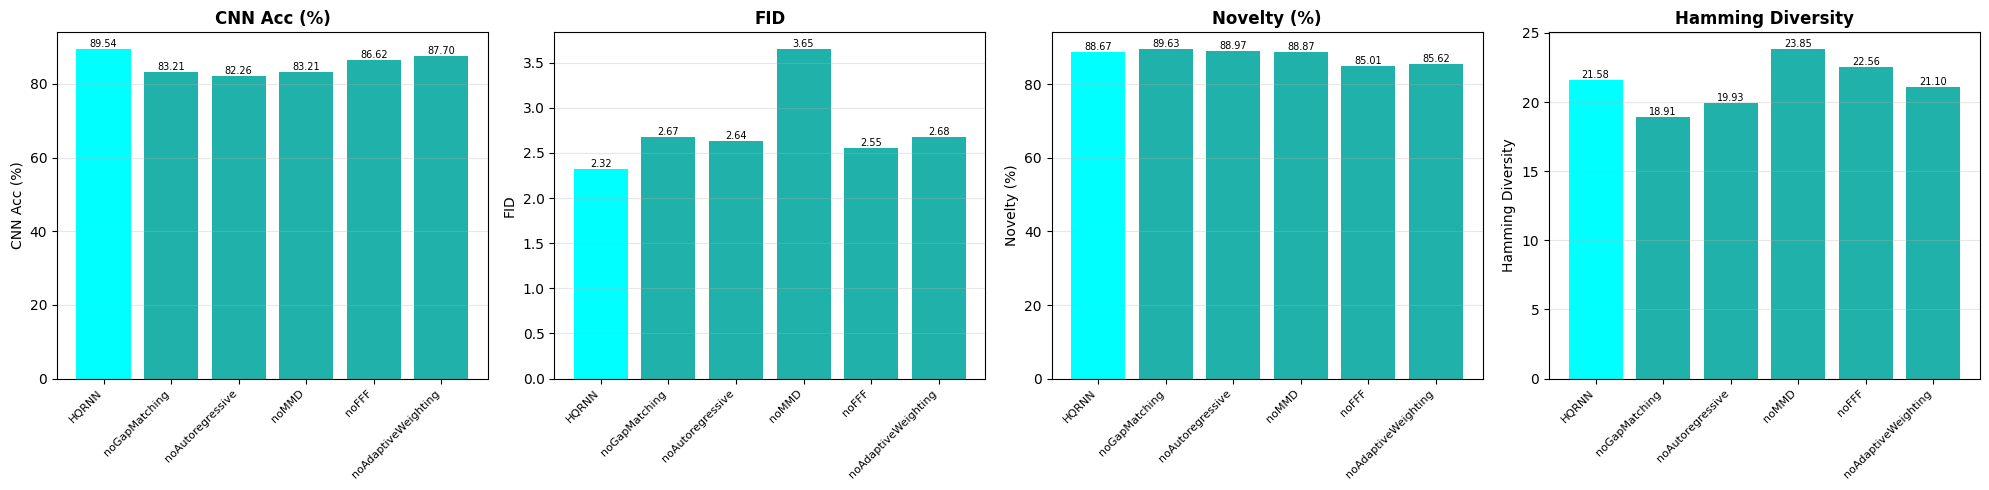

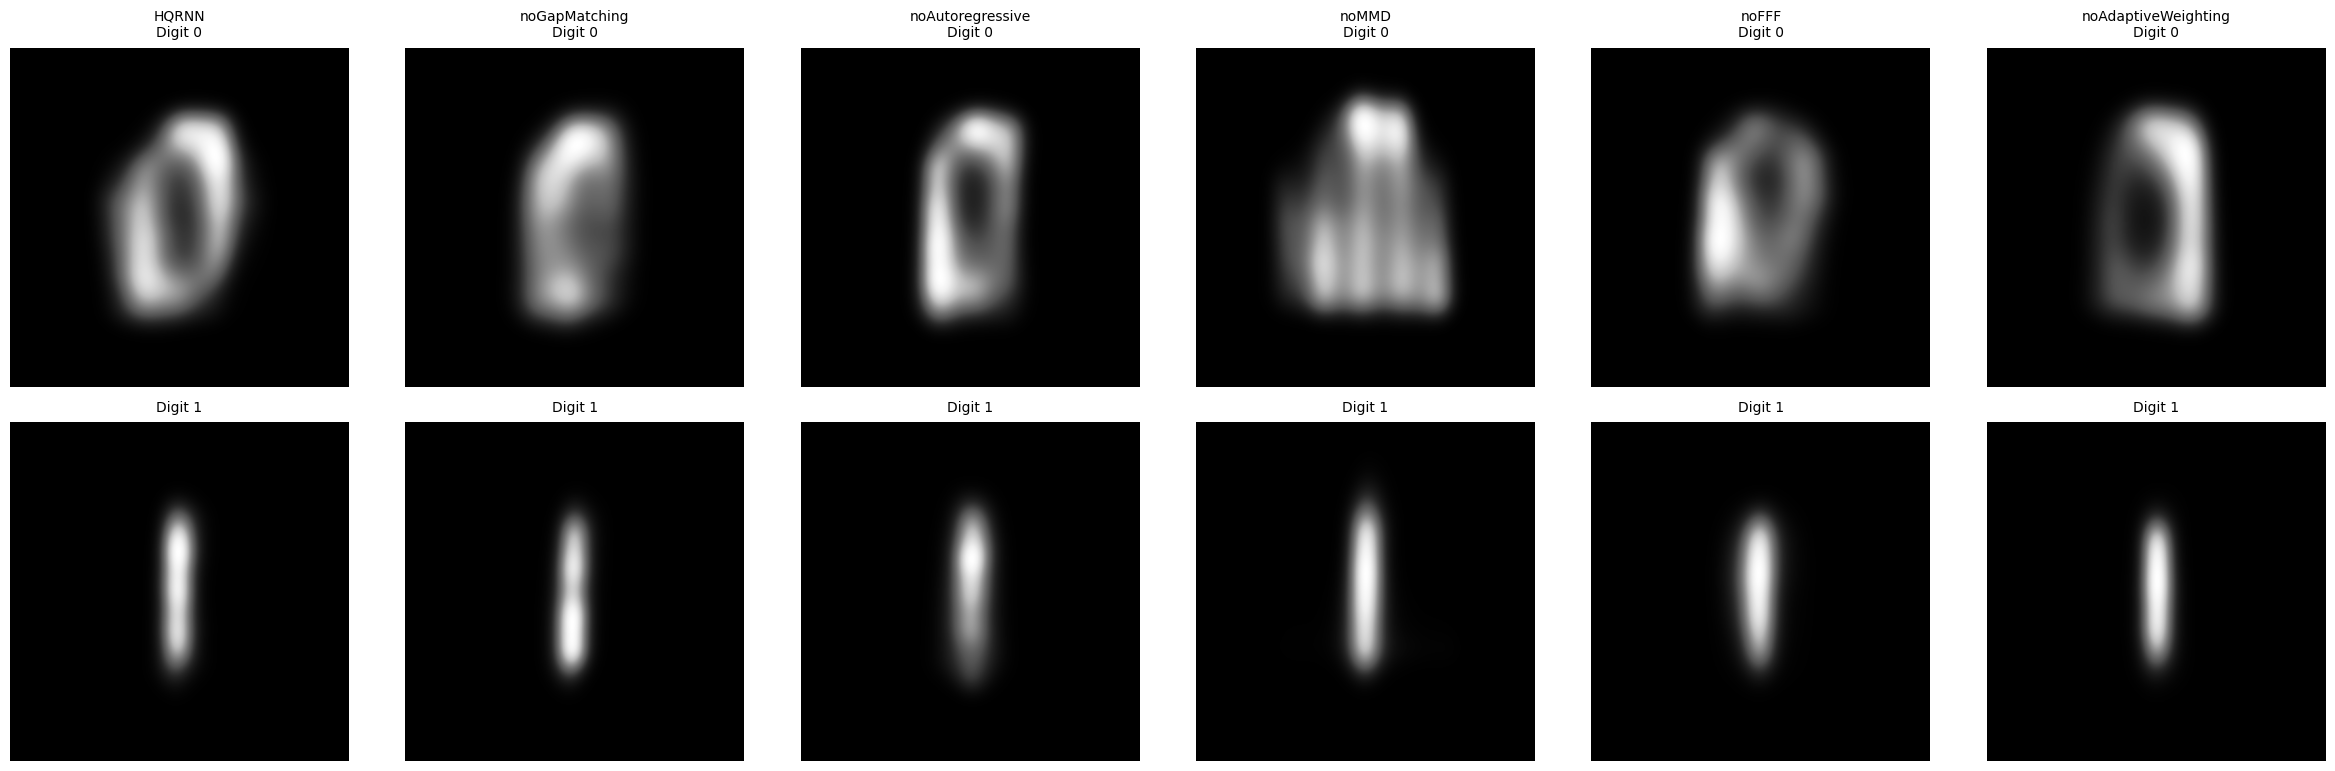

In [ ]:
import os
import pickle
import msgpack
import shutil
import warnings
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
from jax import random, jit, lax
import matplotlib.pyplot as plt
from scipy import ndimage, linalg
from scipy.spatial.distance import cdist
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm
from pathlib import Path
from functools import partial
from PIL import Image
from flax import linen as nn
from flax.training import train_state
import optax

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
plt.rcParams['figure.max_open_warning'] = 0

BASE_DIR = "/content/drive/MyDrive/tongsub/ablation"
DATASET_URL = "https://raw.githubusercontent.com/w-jiwonchoi/HQRNN_dataset/main/model_3_digit.csv"
N_SAMPLES_PER_DIGIT = 5000
KDE_SAMPLES = 5000

print(f"JAX: {jax.__version__}, Devices: {jax.devices()}")

class CNN7x7(nn.Module):
    @nn.compact
    def __call__(self, x, training: bool = False):
        x = jnp.pad(x, ((0, 0), (0, 1), (0, 1), (0, 0)), mode='constant')
        x = nn.Conv(features=32, kernel_size=(3, 3), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = nn.Conv(features=64, kernel_size=(3, 3), padding='SAME')(x)
        x = nn.relu(x)
        x = nn.avg_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = x.reshape((x.shape[0], -1))
        x = nn.Dense(features=128)(x)
        x = nn.relu(x)
        x = nn.Dense(features=1)(x)
        return x

def predict_probabilities(state, images):
    logits = state.apply_fn(state.params, images, training=False).squeeze(axis=-1)
    return jax.nn.sigmoid(logits)

def train_cnn(train_images, train_labels, val_images, val_labels, epochs=50, batch_size=32, learning_rate=0.001):
    print("Training CNN...")
    model = CNN7x7()
    key = random.PRNGKey(GLOBAL_SEED)
    dummy_input = jnp.ones((1, 7, 7, 1))
    params = model.init(key, dummy_input, training=True)
    tx = optax.adam(learning_rate)
    state = train_state.TrainState.create(apply_fn=model.apply, params=params, tx=tx)

    @jax.jit
    def train_step(state, batch_images, batch_labels):
        def loss_fn(params):
            logits = state.apply_fn(params, batch_images, training=True).squeeze(axis=-1)
            loss = optax.sigmoid_binary_cross_entropy(logits, batch_labels.astype(jnp.float32)).mean()
            return loss
        loss, grads = jax.value_and_grad(loss_fn)(state.params)
        return state.apply_gradients(grads=grads), loss

    n_train = len(train_images)
    for epoch in range(epochs):
        key, subkey = random.split(key)
        perm = random.permutation(subkey, n_train)
        epoch_loss = 0.0
        for i in range(0, n_train, batch_size):
            batch_idx = perm[i:i+batch_size]
            state, loss = train_step(state, train_images[batch_idx], train_labels[batch_idx])
            epoch_loss += loss

        if (epoch + 1) % 10 == 0 or epoch == 0:
            val_probs = predict_probabilities(state, val_images)
            val_acc = jnp.mean((val_probs > 0.5) == val_labels) * 100
            print(f"  Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/(n_train/batch_size):.4f}, Val Acc: {val_acc:.2f}%")
    return state

def generate_hqrnn_samples(pkl_path, n_samples, digit):
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    params = data['params']

    saved_cfg = data.get('config', {})
    config = Config(model=3)
    if 'model_cfg' in saved_cfg:
        config.model_cfg = ModelConfig(**saved_cfg['model_cfg'])
    q_model = QuantumModel(config)
    mdl = config.model_cfg
    D, T = mdl.n_D, mdl.seq_len

    powers = 2 ** jnp.arange(D - 1, -1, -1)

    @partial(jit, static_argnames=['label_idx'])
    def generate_one(key, label_idx):
        h = jnp.zeros(2**mdl.n_H, dtype=jnp.complex64).at[0].set(1.0 + 0.0j)

        def body(t, state):
            h_state, x_t, key, rows = state
            key, sk1, sk2 = random.split(key, 3)

            probs = q_model.circuit_for_probs(params, h_state, x_t, label_idx)
            probs = jnp.clip(probs, 0., 1.) / (jnp.sum(jnp.clip(probs, 0., 1.)) + 1e-9)
            idx = random.categorical(sk1, jnp.log(probs))
            bits = (jnp.floor_divide(idx, powers) % 2).astype(jnp.int32)

            full_state = q_model.circuit_for_state(params, h_state, x_t, label_idx)
            psi = jnp.reshape(full_state, (2**mdl.n_H, 2**D))
            h_unnorm = psi[:, idx].astype(jnp.complex64)

            norm = jnp.linalg.norm(h_unnorm)
            h_next = jnp.where(norm > 1e-9, h_unnorm / norm, h_state).astype(jnp.complex64)
            x_next = bits.astype(jnp.float32)

            return (h_next, x_next, key, rows.at[t].set(bits))

        _, _, _, rows = jax.lax.fori_loop(
            0, T, body,
            (h, jnp.zeros(D, dtype=jnp.float32), key, jnp.zeros((T, D), dtype=jnp.int32))
        )
        return rows.flatten()

    samples = []
    base_key = random.PRNGKey(GLOBAL_SEED + digit * 10000)
    for _ in tqdm(range(n_samples), desc=f"Generating digit {digit}", leave=False):
        key, base_key = random.split(base_key)
        samples.append(generate_one(key, digit))
    return np.array(samples)

def calculate_binary_fid(real, gen):
    real, gen = (real > 0.5).astype(np.float32), (gen > 0.5).astype(np.float32)
    mu1, mu2 = real.mean(axis=0), gen.mean(axis=0)
    sigma1, sigma2 = np.cov(real, rowvar=False), np.cov(gen, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if np.iscomplexobj(covmean): covmean = covmean.real
    return float(diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean))

def compute_novelty(real, gen):
    real_binary = (real > 0.5).astype(np.float32)
    gen_binary = (gen > 0.5).astype(np.float32)

    n_real, n_gen = len(real_binary), len(gen_binary)
    n_samples = min(n_real, n_gen, 2000)

    real_subset = real_binary[np.random.choice(n_real, n_samples, replace=False)]
    gen_subset = gen_binary[np.random.choice(n_gen, n_samples, replace=False)]

    X = np.vstack([real_subset, gen_subset])
    y = np.array([0] * n_samples + [1] * n_samples)

    nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree', metric='hamming').fit(X)
    distances, indices = nbrs.kneighbors(X)

    predictions = y[indices[:, 1]]
    accuracy = np.mean(predictions == y) * 100

    return float(accuracy)

def compute_hamming_diversity(gen):
    gen_binary = (gen > 0.5).astype(np.float32)

    n_samples = min(1000, len(gen_binary))
    idx = np.random.choice(len(gen_binary), n_samples, replace=False)
    subset = gen_binary[idx]
    pairwise_dist = cdist(subset, subset, metric='hamming')
    avg_hamming = np.mean(pairwise_dist[np.triu_indices_from(pairwise_dist, k=1)])

    return float(avg_hamming * 100)

def create_kde_stack(images, size=500, scale=60.0, sigma=22.5):
    canvas = np.zeros((size, size), dtype=np.float32)
    center = size / 2.0
    y_grid, x_grid = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')

    for img in images:
        img_2d = img.reshape(7, 7)
        if img_2d.sum() == 0:
            continue

        cy, cx = ndimage.center_of_mass(img_2d)
        if np.isnan(cy):
            continue

        active_pixels = np.argwhere(img_2d > 0.5)
        if len(active_pixels) == 0:
            continue

        for r, c in active_pixels:
            ty = center + (r - cy) * scale
            tx = center + (c - cx) * scale
            dist_sq = (y_grid - ty)**2 + (x_grid - tx)**2
            canvas += np.exp(-dist_sq / (2 * sigma**2))

    if canvas.max() > 0:
        canvas = np.power(canvas / canvas.max(), 4.0)
    return canvas

def ensure_serializable(obj):
    if isinstance(obj, dict):
        return {k: ensure_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [ensure_serializable(x) for x in obj]
    elif hasattr(obj, '__array__'):
        return float(obj) if obj.size == 1 else obj.tolist()
    elif isinstance(obj, (np.integer, jnp.integer)):
        return int(obj)
    elif isinstance(obj, (np.floating, jnp.floating)):
        return float(obj)
    return obj

def main():
    print("Ablation Study Evaluation")
    output_dir = Path(BASE_DIR)
    output_dir.mkdir(parents=True, exist_ok=True)

    print("\nLoading Dataset...")
    df_train = pd.read_csv(DATASET_URL)
    train_imgs = df_train.iloc[:, 1:].values.astype(np.float32).reshape(-1, 7, 7, 1)
    train_lbls = df_train.iloc[:, 0].values

    print("\nTraining CNN...")
    split = int(len(train_imgs)*0.8)
    cnn_state = train_cnn(train_imgs[:split], train_lbls[:split], train_imgs[split:], train_lbls[split:], epochs=50)

    print("\nGenerating Samples...")
    model_names = ['HQRNN', 'noGapMatching', 'noAutoregressive', 'noMMD', 'noFFF', 'noAdaptiveWeighting']
    gen_data = {}

    for name in model_names:
        pkl_path = output_dir / f"{name}.pkl"
        if not pkl_path.exists():
            print(f"{name}.pkl not found, skipping...")
            continue

        try:
            print(f"Processing {name}...")
            d0 = generate_hqrnn_samples(pkl_path, N_SAMPLES_PER_DIGIT, 0)
            d1 = generate_hqrnn_samples(pkl_path, N_SAMPLES_PER_DIGIT, 1)
            full = np.concatenate([d0, d1])
            lbls = np.array([0]*len(d0) + [1]*len(d1))

            gen_data[name] = {'samples': full, 'labels': lbls, 'd0': d0, 'd1': d1}

            df_gen = pd.DataFrame(full)
            df_gen.insert(0, 'label', lbls)
            df_gen.to_csv(output_dir / f"{name}.csv", index=False)
        except Exception as e:
            print(f"Error processing {name}: {e}")

    print("\nEvaluating Models...")
    results = {}
    dataset_flat = train_imgs.reshape(len(train_imgs), -1)

    for name, data in gen_data.items():
        print(f"Computing {name} metrics...")
        samples = data['samples']
        if samples.shape[1] != 49:
            if samples.shape[1] > 49:
                samples = samples[:, :49]
            else:
                samples = np.pad(samples, ((0, 0), (0, 49 - samples.shape[1])), mode='constant')
            data['samples'] = samples

        probs = predict_probabilities(cnn_state, samples.reshape(-1,7,7,1))
        preds = (probs > 0.5).astype(int)
        correct = (preds == data['labels'])

        results[name] = {
            'cnn_acc': int(np.sum(correct)) / len(correct) * 100,
            'fid': calculate_binary_fid(dataset_flat, samples),
            'novelty': compute_novelty(dataset_flat, samples),
            'hamming_div': compute_hamming_diversity(samples)
        }
        print(f"  Acc={results[name]['cnn_acc']:.2f}%, FID={results[name]['fid']:.2f}")

    with open(output_dir / "ablation_results.msgpack", 'wb') as f:
        msgpack.pack(ensure_serializable(results), f)

    print("\nResults Table:")
    print("="*100)
    df_results = pd.DataFrame(results).T
    df_results = df_results[['cnn_acc', 'fid', 'novelty', 'hamming_div']]
    df_results.columns = ['CNN Acc (%)', 'FID', 'Novelty (%)', 'Hamming Diversity']
    print(df_results.to_string(float_format=lambda x: f'{x:.2f}'))
    print("="*100)
    df_results.to_csv(output_dir / "ablation_results_table.csv")

    print("\nCreating Visualizations...")
    fig_bar, axes_bar = plt.subplots(1, 4, figsize=(20, 5))

    metrics = ['cnn_acc', 'fid', 'novelty', 'hamming_div']
    metric_labels = ['CNN Acc (%)', 'FID', 'Novelty (%)', 'Hamming Diversity']

    ordered_names = [n for n in model_names if n in results]

    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        values = [results[name][metric] for name in ordered_names]
        colors = ['#00FFFF' if name == 'HQRNN' else '#20B2AA' for name in ordered_names]

        bars = axes_bar[idx].bar(range(len(ordered_names)), values, color=colors)
        axes_bar[idx].set_title(label, fontsize=12, fontweight='bold')
        axes_bar[idx].set_ylabel(label, fontsize=10)
        axes_bar[idx].set_xticks(range(len(ordered_names)))
        axes_bar[idx].set_xticklabels(ordered_names, rotation=45, ha='right', fontsize=8)
        axes_bar[idx].grid(axis='y', alpha=0.3)

        for bar in bars:
            height = bar.get_height()
            axes_bar[idx].text(bar.get_x() + bar.get_width()/2., height,
                             f'{height:.2f}', ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.savefig(output_dir / "ablation_metrics_comparison.png", dpi=120, bbox_inches='tight')

    print("\nKDE Visualization...")
    n_models = len(gen_data)
    fig, axes = plt.subplots(2, n_models, figsize=(4*n_models, 8))
    if n_models == 1:
        axes = axes.reshape(2, 1)

    for i, name in enumerate(ordered_names):
        if name not in gen_data:
            continue
        d0, d1 = gen_data[name]['d0'], gen_data[name]['d1']

        axes[0, i].imshow(create_kde_stack(d0[:KDE_SAMPLES]), cmap='Greys_r', origin='upper')
        axes[1, i].imshow(create_kde_stack(d1[:KDE_SAMPLES]), cmap='Greys_r', origin='upper')
        axes[0, i].set_title(f"{name}\nDigit 0", fontsize=10, pad=8)
        axes[1, i].set_title(f"Digit 1", fontsize=10, pad=8)
        axes[0, i].axis('off')
        axes[1, i].axis('off')

    plt.tight_layout(pad=2.0)
    plt.savefig(output_dir / "ablation_kde_stack_comparison.png", dpi=120, bbox_inches='tight')

    print("\nAblation Study Complete")
    print(f"Output: {output_dir}")
    print(f"Models: {', '.join(results.keys())}")

if __name__ == '__main__':
    main()

Evaluation Started...

 FINAL EVALUATION RESULTS
           Rate MAE  Value MAE      RMSE  R2 Score  Spearman Corr  \
Model                                                               
Ours         0.8413    55.9843   69.5449    0.9364         0.9797   
MA           1.2463    67.1451   83.9220    0.8955         0.9481   
Momentum     2.1431   115.6809  144.0598    0.6891         0.9155   
LinearReg    0.8176    44.0077   58.5129    0.9492         0.9739   
ARIMA        0.7110    37.9960   62.8607    0.9343         0.9615   

           Total Return (%)  Sharpe Ratio  MDD (%)  
Model                                               
Ours                 0.7111        0.1427 -10.6897  
MA                  -6.5385       -0.7101  -7.8220  
Momentum            -6.0942       -0.6558 -12.9364  
LinearReg           -3.9735       -0.4006 -13.7782  
ARIMA               -1.9637       -0.1643 -11.2642  


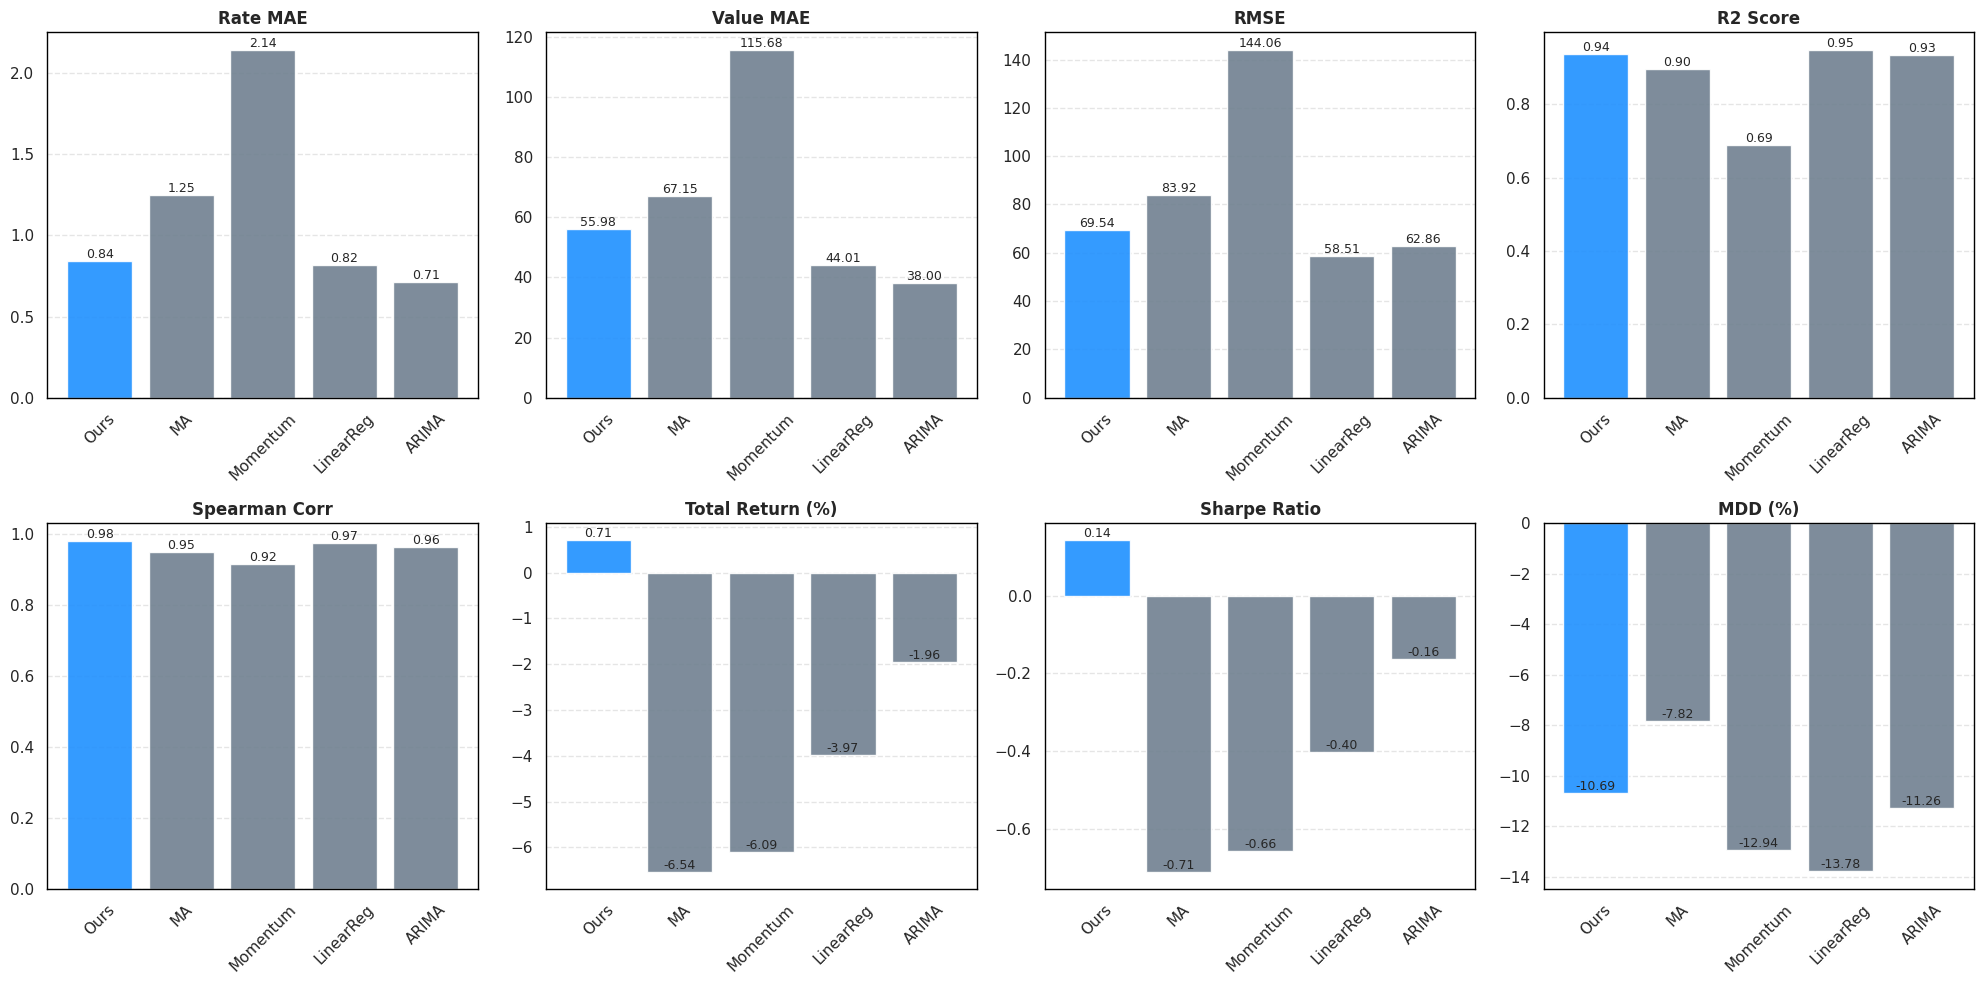

Visualization Completed!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.tsa.ar_model import AutoReg
import warnings

sns.set(style="white")
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings("ignore")

def evaluate_models_final():
    print("Evaluation Started...")

    urls = {
        "Ours": "https://raw.githubusercontent.com/w-jiwonchoi/HQRNN_dataset/refs/heads/main/SnP500_prediction_epoch_final_eval_final.csv",
    }

    try:
        df_o1 = pd.read_csv(urls["Ours"])
    except Exception as e:
        print(f"Error loading CSVs: {e}")
        return

    df = pd.DataFrame({
        'Day': df_o1['Day'],
        'Actual': df_o1['Actual_Value'],
        'Ours': df_o1['Predicted_Value'],
    })

    seq_len = 10

    # 1. Generate Baseline Models
    df['MA'] = df['Actual'].rolling(window=seq_len).mean().shift(1)
    pct_change_10 = df['Actual'].pct_change(periods=seq_len)
    df['Momentum'] = df['Actual'].shift(1) * (1 + pct_change_10.shift(1))

    preds_lr = [np.nan] * len(df)
    preds_arima = [np.nan] * len(df)

    for t in range(seq_len, len(df)):
        train_y = df['Actual'].iloc[:t].values
        window_y = train_y[-seq_len:]
        window_x = np.arange(seq_len).reshape(-1, 1)

        lr_model = LinearRegression()
        lr_model.fit(window_x, window_y)
        preds_lr[t] = lr_model.predict([[seq_len]])[0]

        try:
            ar_model = AutoReg(train_y, lags=seq_len, old_names=False)
            ar_fit = ar_model.fit()
            preds_arima[t] = ar_fit.forecast(steps=1)[0]
        except:
            preds_arima[t] = np.nan

    df['LinearReg'] = preds_lr
    df['ARIMA'] = preds_arima
    df['Actual_Rate'] = df['Actual'].pct_change()

    # 2. Prepare Data for Backtesting
    valid_idx = df.dropna().index
    sim_df = df.loc[valid_idx].copy()
    sim_df['Next_Ret'] = sim_df['Actual'].pct_change().shift(-1)

    sim_df = sim_df.dropna()

    models = ['Ours', 'MA', 'Momentum', 'LinearReg', 'ARIMA']
    results_list = []

    # 3. Calculate Metrics
    for model_name in models:
        pred_series = df[model_name]
        actual_series = df['Actual']
        common_idx = pred_series.dropna().index.intersection(actual_series.dropna().index)

        curr_pred = pred_series.loc[common_idx]
        curr_actual = actual_series.loc[common_idx]
        prev_actual = df['Actual'].shift(1).loc[common_idx]

        if "Ours" in model_name:
            model_rate = df[model_name].pct_change().loc[common_idx]
        else:
            model_rate = (curr_pred - prev_actual) / prev_actual

        rate_diff = np.abs(df['Actual_Rate'].loc[common_idx] - model_rate)
        rate_mae = rate_diff.mean() * 100

        value_diff = np.abs(curr_actual - curr_pred)
        value_mae = value_diff.mean()

        mse = (value_diff ** 2).mean()
        rmse = np.sqrt(mse)

        if len(curr_actual) > 1:
            r2 = r2_score(curr_actual, curr_pred)
        else:
            r2 = np.nan

        spearman_corr = curr_pred.corr(curr_actual, method='spearman')

        model_sim = sim_df[['Actual', 'Next_Ret', model_name]].dropna()

        signal = np.sign(model_sim[model_name] - model_sim['Actual'])
        strategy_ret = signal * model_sim['Next_Ret']
        cum_ret = (1 + strategy_ret).cumprod()

        total_return = (cum_ret.iloc[-1] - 1) * 100

        volatility = strategy_ret.std() * np.sqrt(252)
        if volatility == 0:
            sharpe = 0
        else:
            sharpe = (strategy_ret.mean() * 252) / volatility

        rolling_max = cum_ret.cummax()
        drawdown = cum_ret / rolling_max - 1.0
        mdd = drawdown.min() * 100

        results_list.append({
            "Model": model_name,
            "Rate MAE": rate_mae,
            "Value MAE": value_mae,
            "RMSE": rmse,
            "R2 Score": r2,
            "Spearman Corr": spearman_corr,
            "Total Return (%)": total_return,
            "Sharpe Ratio": sharpe,
            "MDD (%)": mdd
        })

    results_df = pd.DataFrame(results_list).set_index("Model")

    print("\n" + "="*80)
    print(" FINAL EVALUATION RESULTS")
    print("="*80)
    print(results_df.round(4))
    results_df.to_csv("final_model_comparison.csv")

    # 4. Visualization
    metrics = ["Rate MAE", "Value MAE", "RMSE", "R2 Score",
               "Spearman Corr", "Total Return (%)", "Sharpe Ratio", "MDD (%)"]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    colors = ['dodgerblue' if 'Ours' in idx else 'slategray' for idx in results_df.index]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        if results_df[metric].notna().any():
            bars = ax.bar(results_df.index, results_df[metric], color=colors, edgecolor=None, alpha=0.9)

            ax.set_title(metric, fontsize=12, fontweight='bold')
            ax.set_xticklabels(results_df.index, rotation=45)

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color('black')
                spine.set_linewidth(1)

            ax.grid(axis='y', linestyle='--', alpha=0.5)
            ax.grid(axis='x', visible=False)
            ax.tick_params(left=False, bottom=False)

            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.2f}',
                        ha='center', va='bottom', fontsize=9)
        else:
            ax.set_title(f"{metric} (No Data)", fontsize=12)
            ax.axis('off')

    plt.tight_layout()
    plt.show()
    print("Visualization Completed!")

if __name__ == "__main__":
    evaluate_models_final()